In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import spatial
import seaborn as sns
import copy
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# df = df.drop([0, 7]) #删除已知的两条脏数据
df = pd.read_csv('样本1.csv')
#df = pd.read_excel(r"xxx")
y_name ='价格_万元'

C:\Users\1\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\1\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [ ]:
# Cell 1: 导入库和配置
import pymc3 as pm
import arviz as az
import matplotlib
import warnings
warnings.filterwarnings("ignore")

# 配置参数
FILE_PATH = "液压作动器采购数据表.xlsx"
PRICE_COL = "名义单价_万元"
QTY_COL = "采购批量_件"
DATE_COL = "采购日期"
BASE_YEAR = 2025

PPI_DICT = {
    2020: 97.7,
    2021: 98.3,
    2022: 99.8,
    2023: 100.0,
    2024: 100.1,
    2025: 100.0
}

print("✅ 库导入和配置完成")

In [ ]:
# Cell 2: 定义工具函数
def check_columns(df, cols):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"文件缺少必要列: {missing}\n当前列名: {list(df.columns)}")

def safe_log(x):
    x = np.asarray(x, dtype=float)
    if np.any(x <= 0):
        raise ValueError("存在非正数，无法取对数，请检查价格和批量字段。")
    return np.log(x)

def build_ppi_mapping(df_years, ppi_dict):
    years = sorted(set(df_years))
    missing_years = [y for y in years if y not in ppi_dict]
    if missing_years:
        raise ValueError(
            f"PPI 字典缺少这些年份: {missing_years}\n"
            f"已提供年份: {sorted(ppi_dict.keys())}"
        )
    return ppi_dict

def time_adjust_price(df, price_col, year_col, ppi_dict, base_year):
    df = df.copy()
    df["ppi"] = df[year_col].map(ppi_dict)
    
    if df["ppi"].isna().any():
        raise ValueError("存在无法匹配到PPI的年份，请检查 PPI_DICT。")
    
    if base_year not in ppi_dict:
        raise ValueError(f"基准年 {base_year} 不在 PPI_DICT 中。")
    
    ppi_base = ppi_dict[base_year]
    df["price_time_adj"] = df[price_col] * (ppi_base / df["ppi"])
    df["base_year"] = base_year
    return df

print("✅ 工具函数定义完成")

In [ ]:
# Cell 3: 定义贝叶斯模型函数
def fit_bayesian_learning_curve(df, adj_price_col, qty_col):
    y = df[adj_price_col].values.astype(float)
    q = df[qty_col].values.astype(float)
    
    if len(y) < 3:
        raise ValueError("样本太少，至少需要 3 个样本点。")
    
    log_y = safe_log(y)
    log_q = safe_log(q)
    
    q_mean = log_q.mean()
    q_std = log_q.std() if log_q.std() > 1e-8 else 1.0
    x = (log_q - q_mean) / q_std
    
    with pm.Model() as model:
        alpha = pm.Normal("alpha", mu=np.mean(log_y), sigma=np.std(log_y) + 1.0)
        lambda_ = pm.Normal("lambda", mu=0.25, sigma=0.05)
        sigma = pm.HalfNormal("sigma", sigma=1.0)
        
        mu = alpha - lambda_ * (log_q - q_mean)
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=log_y)
        
        trace = pm.sample(
            draws=2000,
            tune=2000,
            chains=2,
            target_accept=0.9,
            random_seed=42,
            progressbar=True,
        )
    
    return model, trace, q_mean

def summarize_posterior(trace):
    return az.summary(trace, var_names=["alpha", "lambda", "sigma"], hdi_prob=0.95)

print("✅ 贝叶斯模型函数定义完成")

In [ ]:
# Cell 4: 数据读取和预处理
# 检查必要列
check_columns(df, [PRICE_COL, QTY_COL, DATE_COL])

# 只保留必要列
df2 = df[[PRICE_COL, QTY_COL, DATE_COL]].copy()

# 查看数据概况
print("\n📅 数据年份分布:")
print(df2[DATE_COL].value_counts().sort_index())

In [ ]:
# Cell 5: 数据清洗
# 缺失值统计
print("🔍 缺失值统计：")
print(df2[[PRICE_COL, QTY_COL, DATE_COL]].isna().sum())

# 删除价格和年份缺失的行
df2 = df2.dropna(subset=[PRICE_COL, DATE_COL])

if df.empty:
    raise ValueError("清洗后样本为空，请检查原始数据。")

df2[DATE_COL] = df2[DATE_COL].astype(int)

print(f"\n✅ 清洗后数据形状: {df2.shape}")
print(f"\n📈 数据统计:")
print(df2[[PRICE_COL, QTY_COL]].describe())

In [ ]:
# Cell 6: 数据可视化 - 清洗后的数据
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 价格分布
axes[0].hist(df2[PRICE_COL], bins=20, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('名义单价 (万元)')
axes[0].set_ylabel('频数')
axes[0].set_title('价格分布')
axes[0].grid(True, alpha=0.3)

# 批量分布
axes[1].scatter(df2[QTY_COL], df2[PRICE_COL], alpha=0.6)
axes[1].set_xlabel('采购批量 (件)')
axes[1].set_ylabel('名义单价 (万元)')
axes[1].set_title('价格 vs 批量')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Cell 7: 时间校正
# 检查 PPI
build_ppi_mapping(df2[DATE_COL], PPI_DICT)

# 时间校正
df_adj = time_adjust_price(df2, PRICE_COL, DATE_COL, PPI_DICT, BASE_YEAR)

print("==== 时间校正后的样本预览 ====")
print(df_adj.head(10))
print(f"\n✅ 已校正到 {BASE_YEAR} 年价格水平")

In [ ]:
# Cell 8: 贝叶斯模型训练
print("🔄 开始贝叶斯模型训练...")
model, trace, q_mean = fit_bayesian_learning_curve(df_adj, "price_time_adj", QTY_COL)
print("✅ 模型训练完成")

In [ ]:
#后验结果分析
summary = summarize_posterior(trace)
print("==== 后验估计结果 ====")
print(summary)

# 保存结果
summary.to_csv("posterior_summary.csv", encoding="utf-8-sig")
print("\n✅ 后验摘要已保存到 posterior_summary.csv")

In [ ]:
# Cell 10: 模型诊断图
# 绘制trace图
az.plot_trace(trace, figsize=(12, 8))
plt.tight_layout()
plt.savefig("trace_plot.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ 诊断图已保存到 trace_plot.png")

In [ ]:
#后验分布图
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']  
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# alpha 后验分布
az.plot_posterior(trace, var_names=["alpha"], ax=axes[0])
axes[0].set_title('Alpha 后验分布')

# lambda 后验分布
az.plot_posterior(trace, var_names=["lambda"], ax=axes[1])
axes[1].set_title('Lambda (学习率) 后验分布')

# sigma 后验分布
az.plot_posterior(trace, var_names=["sigma"], ax=axes[2])
axes[2].set_title('Sigma 后验分布')

plt.tight_layout()
plt.show()

In [ ]:
lambda_mean = trace["lambda"].mean()
STANDARD_QTY=100
df_adj["price_time_batch_adj"] = (df_adj["price_time_adj"]*(df_adj[QTY_COL]/STANDARD_QTY)**lambda_mean)
df_adj.to_csv("time_batch_adjusted_price.csv",index=False,encoding="utf-8-sig")

In [2]:
df_describe=df[y_name].describe()
df_std=df_describe.loc['std']
df_std

52.62343549470431

In [3]:
# 去除离群样本
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# 标准化数据
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.loc[:, df.columns[1]:df.columns[-1]])

# 创建IsolationForest模型
clf = IsolationForest(contamination=0.05, random_state=42)
clf.fit(scaled_data)
#训练模型并预测异常值
df['is_outlier'] = clf.predict(scaled_data)
# df

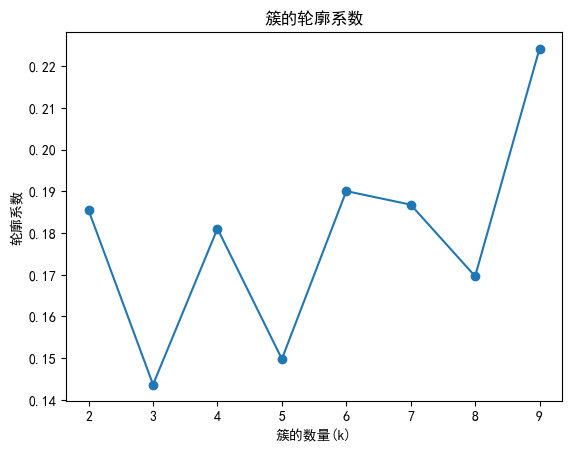

In [4]:
#忽略warning
import warnings
warnings.filterwarnings('ignore')
# 聚类，看看聚类标签与价格标签是否一致
# 找到最佳的k-轮廓系数法
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
silhouette_scores = []

k_values = range(2,10)
n_runs=10
for k in k_values:
    all_cluster_assignments = []
    for i in range(n_runs):
        kmeans = KMeans(n_clusters = k, random_state=42)
        kmeans.fit(scaled_data)
        all_cluster_assignments.append(kmeans)
    
    # 通过比较不同运行的簇内平方和来选择最优结果
    best_cluster_assignment = min(all_cluster_assignments, key = lambda x: x.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, best_cluster_assignment.labels_))
    
# 绘制轮廓系数法图形
plt.plot(k_values, silhouette_scores, marker = 'o')
plt.xlabel('簇的数量(k)')
plt.ylabel('轮廓系数')
plt.title('簇的轮廓系数')
plt.show()

In [5]:
# 聚类，看看聚类标签与价格标签是否一致
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 标准化数据
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.loc[:,df.columns[1]:df.columns[-1]])
# 设置聚类的簇数
num_clusters = 4

# 运行10次KMeans，比较簇内平方和，选择最佳模型
n_runs = 10
best_kmeans = None
lowest_inertia = float('inf')  # 初始化最小簇内平方和
best_cluster_assignments = None

for i in range(n_runs):
    kmeans = KMeans(n_clusters=num_clusters, random_state=i)
    cluster_assignments = kmeans.fit_predict(scaled_data)
    
    if kmeans.inertia_ < lowest_inertia:  # 比较簇内平方和
        lowest_inertia = kmeans.inertia_
        best_kmeans = kmeans  # 保存当前最佳模型
        best_cluster_assignments = cluster_assignments

# # 使用K_means聚类，运行10次
# n_runs=10
# all_cluster_assignments = []
# for i in range(n_runs):
#     kmeans = KMeans(n_clusters = num_clusters, random_state=i)
#     cluster_assignments = kmeans.fit_predict(scaled_data)
#     all_cluster_assignments.append(cluster_assignments)
    
# # 通过比较不同运行的簇内平方和来选择最优结果
# best_cluster_assignment = min(all_cluster_assignments, key = lambda x: kmeans.inertia_)
df['Cluster'] = best_cluster_assignments
# df

In [6]:
# 设置价格区间
# df['价格类别'] = pd.cut(df['价格'], bins = [float('-inf'),35000,70000,105000,140000,175000,210000,245000,float('inf')],labels=[0,1,2,3,4,5,6,7])
# df['价格类别'] = pd.cut(df['价格'], bins = [float('-inf'),188103,245606,326251,float('inf')],labels=[0,1,2,3])
# df.to_excel('price_class_cluster_label_data1.xlsx', index=True)
df['价格类别'] = pd.qcut(df['价格_万元'], q=num_clusters, labels=range(num_clusters))
price_bins = pd.qcut(df['价格_万元'], q=num_clusters, retbins=True)
print(price_bins[1])  # 输出生成的边界区间

# 将结果保存到 Excel
df.to_excel('price_class_cluster_label_data.xlsx', index=False)

print(df[['价格_万元', '价格类别']].head())

[  3.    20.5   41.    63.25 300.  ]
   价格_万元 价格类别
0   28.0    1
1   85.0    3
2   42.0    2
3   35.0    1
4   92.0    3


In [7]:
df = df[(df['is_outlier'] != -1) ]

In [8]:
cross_tab = pd.crosstab(df['价格类别'],df['Cluster'])

Text(0.5, 1.0, 'Correlation Heatmap: 价格类别 vs. cluster')

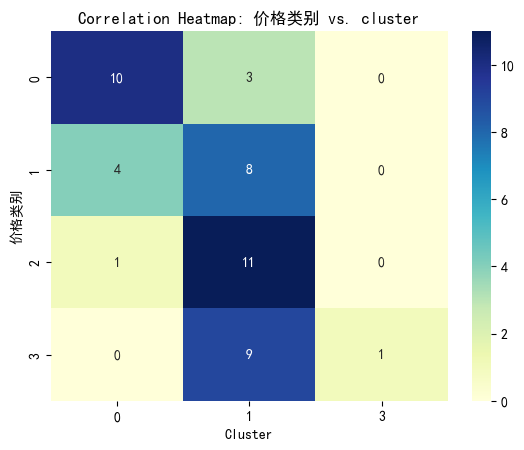

In [9]:
import seaborn as sns
heatmap_data = cross_tab

# 绘制热力图
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Correlation Heatmap: 价格类别 vs. cluster')

In [10]:
from sklearn.model_selection import train_test_split
import random
# 生成一个随机数种子并保存到变量中
randomnumber = random.randint(1, 10000)
#numbers = [2491,9812,6613,5415,2045,1002,4692,4711,1008,6803,8261,347,7471,1917,2527,4753,4860,8411,7657,8388,5657,5638]
#randomnumber = random.choice(numbers)
print("随机数种子：",randomnumber)
# 价格分层抽样
df = df.drop(columns=['is_outlier'])
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['价格类别'], random_state=randomnumber)
# 删除”价格类别"列
train_df = train_df.drop(columns=['价格类别'])
test_df = test_df.drop(columns=['价格类别'])
# train_df, test_df

随机数种子： 2263


In [11]:
import pickle
df_X = df.loc[:,df.columns[1]:'Cluster'].drop(columns=[y_name,"Cluster"])
df_y = df[y_name]
#X_train = train_df.loc[:,df.columns[1]:'Cluster']
X_train = train_df.loc[:, df.columns[1]:].drop(columns=[y_name,"Cluster"])
y_train = train_df[y_name]
y_train = np.log(y_train)
#X_test = test_df.loc[:, df.columns[1]:'Cluster']
X_test = test_df.loc[:, df.columns[1]:].drop(columns=[y_name,"Cluster"])
y_test = test_df[y_name]
# 打印训练数据集和测试数据集的观测数量
print('训练数据集共有%d条观测' % X_train.shape[0])
print('测试数据集共有%d条观测' % X_test.shape[0])
# y_train
# y_test
feature_names = X_train.columns.tolist()
print("保存特征列:")
print(feature_names)
with open("feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)
print("训练第一条:")
print(X_train.iloc[0])

print("\n测试第一条:")
print(X_test.iloc[0])

训练数据集共有37条观测
测试数据集共有10条观测
保存特征列:
['压力_bar', '出力_kN', '行程_mm', '速度_mm_s', '温度_min_°C', '温度_max_°C', 'MTBF_小时', '重量_kg', '功率_kW', '泄漏_mL_min', '响应时间_ms', '控制方式', '适用机型', '材料类型', '密封等级', '液压油类型', '流量_L_min', '固有频率_Hz', '阻尼系数', '冗余配置', '认证等级', '维护周期_小时', '故障率_10e6_FH', '安装方式', '接口类型']
训练第一条:
压力_bar          210.00
出力_kN            15.00
行程_mm           450.00
速度_mm_s          35.00
温度_min_°C        30.00
温度_max_°C        70.00
MTBF_小时        8500.00
重量_kg            12.00
功率_kW             0.52
泄漏_mL_min         0.00
响应时间_ms          42.00
控制方式              3.00
适用机型              3.00
材料类型              3.00
密封等级              3.00
液压油类型             2.00
流量_L_min         40.00
固有频率_Hz          46.00
阻尼系数              0.52
冗余配置              3.00
认证等级              3.00
维护周期_小时        3500.00
故障率_10e6_FH       2.10
安装方式              1.00
接口类型              2.00
Name: 34, dtype: float64

测试第一条:
压力_bar           165.0
出力_kN             30.0
行程_mm            100.0
速度_mm_s           50.0
温度_min_°C  

In [12]:
# 数据标准化
from sklearn.preprocessing import MinMaxScaler  
print(X_train.head())
scaler = MinMaxScaler(feature_range=(0, 1))  # 指定缩放的范围  
scaler.fit(X_train)  # 用训练集的数据来拟合scaler 
print("fit scaler之前 X_train:")
print(X_train.head())

print("\n最小值:")
print(X_train.min())

print("\n最大值:")
print(X_train.max())
# with open("scaler.pkl","wb") as f:
#         pickle.dump(scaler,f)
import pickle

pickle.dump(scaler, open("minmax.pkl","wb"))  #保存
with open("minmax.pkl","rb") as f:
    scaler = pickle.load(f)
print(type(scaler))
print(hasattr(scaler,"transform"))   #检验

# 用训练集的数据来拟合scaler并进行标准化
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # 注意这里使用transform而不是apply

# 保存原始的X_test
X_test_original = X_test.copy()

# 将标准化后的数组转换回DataFrame
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
print(X_train.shape)
print(X_test.shape)

# X_train

X_test.to_excel('X_test.xlsx')
y_test.to_excel('y_test.xlsx')
print("训练第一条:")
print(X_train.iloc[0])

print("\n测试第一条:")
print(X_test.iloc[0])
print(y_train.head())
print(y_train.describe())

    压力_bar  出力_kN  行程_mm  速度_mm_s  温度_min_°C  温度_max_°C  MTBF_小时  重量_kg  \
34   210.0   15.0  450.0     35.0         30         70     8500   12.0   
41   207.0   35.0   63.0     61.0         40        120    17000   19.0   
4    350.0  155.0  160.0    160.0         60        100    25000   40.0   
32   165.0   95.0  450.0    250.0         40        100    15000   42.0   
23   207.0  144.0  104.0    226.0         40        100    40000    8.0   

    功率_kW  泄漏_mL_min  ...  液压油类型  流量_L_min  固有频率_Hz  阻尼系数  冗余配置  认证等级  \
34   0.52        0.0  ...      2      40.0     46.0  0.52     3     3   
41  85.00      480.0  ...      1     175.0     82.0  0.55     3     1   
4   24.80       10.0  ...      1     180.0     22.0  0.68     4     2   
32  23.80       28.0  ...      3     145.0     16.0  0.70     3     1   
23  69.00        0.0  ...      1     118.0     66.0  1.00     3     3   

    维护周期_小时  故障率_10e6_FH  安装方式  接口类型  
34     3500         2.10     1     2  
41     6000         1.40     2  

In [13]:
# In[15]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# # 创建线性回归模型
# linear_model = LinearRegression()
# # 通过交叉验证选择最佳模型
# predict = cross_val_predict(linear_model, X_train, y_train, cv=10)  # 使用 10 折交叉验证

# # 在训练集上训练模型
# linear_model.fit(X_train, y_train)
# # 在测试集上进行预测
# linear_predictions = linear_model.predict(X_test)
# max_allowed_log_value = np.log(np.finfo(np.float64).max)
# linear_predictions = np.clip(linear_predictions,a_min=None,a_max=max_allowed_log_value)
# linear_predictions = np.exp(linear_predictions)

# 模型分析
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred) / y_true) * 100
# # 计算平均绝对百分比误差
# model1_mape = mean_absolute_percentage_error(y_test, linear_predictions)

# print("LR模型的平均绝对百分比误差：", model1_mape)
# # 计算每个样本的残差
# residuals = np.exp(y_train)-np.exp(predict)
# #计算残差的标准差作为置信度估计
# confidence = np.std(residuals)
# model1_mse = mean_squared_error(y_test,  linear_predictions)
# print("均方误差 (MSE):", model1_mse)
# model1_rmse = np.sqrt(model1_mse)
# print("均方根误差 (RMSE):", model1_rmse)
# model1_mae = mean_absolute_error(y_test,  linear_predictions)
# print("平均绝对误差 (MAE):", model1_mae)
# model1_r2 = r2_score(y_test,  linear_predictions)
# print("R^2 得分:", model1_r2)
# print("预测值的置信度（标准差）：",confidence)

In [14]:
def draw_result(predictions, X_test, y_test):
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
    X = range(1, len(X_test) + 1)
    bar_width = 0.4  # 柱状图宽度

    plt.figure(figsize=(16, 9))
    error = np.abs(np.array(y_test) - np.array(predictions)) / 2
    # 将折线图改为分组柱状图
    plt.bar(X, y_test, width=bar_width, label='真实值', color='orange', alpha=0.5)
    plt.bar([x + bar_width for x in X], predictions, width=bar_width, label='预测值', color='b', alpha=0.5,
           yerr = error, capsize=5)
    mapes =  np.abs(y_test - predictions) / y_test
    # 添加误差值标签
    for x, y, mape in zip(X, predictions, mapes):
        plt.text(x + bar_width, y + mape + 0.01, '{:.2%}'.format(mape), ha='left',  fontsize=12 )


    plt.ylabel('价格', fontsize=20)
    plt.xlabel('测试集', fontsize=20)
    plt.tick_params(labelsize=20)
    plt.legend(['真实值', '预测值'], fontsize=30)
    plt.title('在测试集上的预测效果', fontsize=30)
    plt.xticks([x + bar_width / 2 for x in X], X)
    plt.savefig('result.png')
    plt.show()
    #把图片保存到本地

In [15]:
from matplotlib.ticker import FuncFormatter
def draw_mapes_hist(y_test, predictions):
    mapes = np.abs(y_test - predictions) / y_test

    plt.hist(mapes, bins = 5, color = 'blue', alpha =0.7)
    def percent_format(x, pos):
        return f'{x * 100:.2f}%'

    plt.gca().xaxis.set_major_formatter(FuncFormatter(percent_format))
    plt.xlabel('值')
    plt.ylabel('频数')
    plt.title('mape直方图')
    plt.show()

In [16]:
from sklearn.utils import resample
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score

# 计算置信区间 直接计算法
def calculate_confidence_intervals(predicted_values, std_devs):
    z_value = 1 

    lower_bounds = predicted_values - z_value * std_devs
    upper_bounds = predicted_values + z_value * std_devs

    return lower_bounds, upper_bounds


#新的三条标准
def new_3_indictors(df_X, df_y, X_test, y_test, pred, model, model_name):
 
    # 1. 计算 R² 分数
    r2 = r2_score(y_test, pred)
    print(f'R² score: {r2}')

    
    
    residuals = y_test-pred
#计算残差的标准差作为置信度估计
#     confidence = np.std(residuals)
    confidence = np.std(pred)

    lower_bounds, upper_bounds = calculate_confidence_intervals(pred, confidence)

    ci_width = upper_bounds - lower_bounds

    print(f'Confidence Interval Width: {ci_width}')

    
    
    # 3. 计算模型稳定性（使用平均绝对误差百分比）
    n_splits = min(5, len(X_test))  # 确保 n_splits 小于等于样本数量
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=1) # 交叉验证
    mape_scores = []

    for train_index, test_index in cv.split(df_X):
        X_cv_train, X_cv_test = df_X.iloc[train_index], df_X.iloc[test_index]
        y_cv_train, y_cv_test = df_y.iloc[train_index], df_y.iloc[test_index]
        model.fit(X_cv_train, y_cv_train)  # 重新训练模型
        y_cv_pred = model.predict(X_cv_test)
        mape = mean_absolute_percentage_error(y_cv_test, y_cv_pred)
        mape_scores.append(mape)

    # 计算MAPE的标准差和平均值
    mape_scores = np.array(mape_scores)
    stability = np.std(mape_scores)
    print(f'Model Stability (Std of MAPE): {stability}')

    # 输出评估结果
    if r2 > 0.6:
        print("R² score is acceptable.")
    else:
        print("R² score is too low.")

    specific_width_value = df_std*2  # bootstap置信区间宽度阈值
    if np.mean(ci_width) < specific_width_value:
        print("Confidence interval width is acceptable.")
    else:
        print("Confidence interval width is too wide.")
        
    specific_stability_value = 20  # 稳定性阈值百分比
    if stability < specific_stability_value:
        print("Model stability is acceptable.")
    else:
        print("Model stability is too low.")
        
    return r2, ci_width, stability

In [17]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import pickle

def expert_weighted_lasso_regression(X_train, y_train, X_test, y_test, expert_map):
    # 保证是 DataFrame
    X_train_scaled = pd.DataFrame(X_train).copy()
    X_test_scaled = pd.DataFrame(X_test).copy()
    print(X_train_scaled.shape)
    print(X_test_scaled.shape)

    # 只对数值特征做处理
    num_cols = X_train.columns.tolist()
    print(num_cols)

    # 1. 标准化
#     scaler = StandardScaler()
#     X_train_scaled = pd.DataFrame(
#         scaler.fit_transform(X_train),
#         columns=num_cols,
#         index=X_train.index
#     )
#     X_test_scaled = pd.DataFrame(
#         scaler.transform(X_test),
#         columns=num_cols,
#         index=X_test.index
#     )

    # 2. 构造专家权重
    weights = {}
    for col in num_cols:
        s = expert_map.get(col, 1.0)
        if s is None or pd.isna(s) or not np.isfinite(s):
            s = 1.0
        s = float(s)
        s = max(1.0, min(5.0, s))
        # 映射到 0.5 ~ 2.5
        weights[col] = 0.5+ (s - 1.0) / 4.0 * 2.5

    # 3. 对特征做专家加权缩放
    for col in num_cols:
        X_train_scaled[col] *= weights[col]
        X_test_scaled[col] *= weights[col]

    # 4. 搜索最佳 alpha
    alphas = [0.0001, 0.001, 0.01]
    best_alpha = None
    best_mae = float('inf')

    for alpha in alphas:
        model = Lasso(alpha=alpha, max_iter=10000)
        model.fit(X_train_scaled, y_train)
        pred_log = model.predict(X_test_scaled)
        pred = np.exp(pred_log)

        # 如果 y_test 也是 log，需要先还原
        y_true = np.exp(y_test) if np.max(y_test) < 50 else y_test

        mae = mean_absolute_error(y_true, pred)
        if mae < best_mae:
            best_mae = mae
            best_alpha = alpha

    print("最佳 alpha:", best_alpha)

    # 5. 用最佳 alpha 重新训练
    lasso_model = Lasso(alpha=best_alpha, max_iter=10000)
    lasso_model.fit(X_train_scaled, y_train)

    pred_log = lasso_model.predict(X_test_scaled)
    pred = np.exp(pred_log)
    y_true = np.exp(y_test) if np.max(y_test) < 50 else y_test

    residuals = y_true - pred
    std_dev = np.std(residuals)

    mse = mean_squared_error(y_true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, pred)
    r2 = r2_score(y_true, pred)
    mape = mean_absolute_percentage_error(y_true, pred)

    print("均方误差 (MSE):", mse)
    print("均方根误差 (RMSE):", rmse)
    print("平均绝对误差 (MAE):", mae)
    print("R^2 得分:", r2)
    print("平均绝对百分比误差:", mape)
    lower_bounds, upper_bounds = calculate_confidence_intervals(pred, std_dev)
    confidence_intervals = list(zip(lower_bounds, upper_bounds))
    print("95% 的置信区间列表:", confidence_intervals)


    return lasso_model, pred, weights,X_train_scaled.columns.tolist()

expert_map = {
    "压力_bar": 5, "出力_kN": 5, "行程_mm": 4, "速度_mm_s": 4,
    "温度_min_°C": 2, "温度_max_°C": 2, "MTBF_小时": 4, "重量_kg": 3,
    "功率_kW": 4, "泄漏_mL_min": 2, "响应时间_ms": 4, "控制方式": 3,
    "适用机型": 2, "材料类型": 4, "密封等级": 4, "液压油类型": 2,
    "流量_L_min": 4, "固有频率_Hz": 3, "阻尼系数": 2, "冗余配置": 3,
    "认证等级": 3, "维护周期_小时": 2, "故障率_10e6_FH": 3,
    "安装方式": 1, "接口类型": 1
}
lasso_model, lasso_predictions, expert_weights,feature_names = expert_weighted_lasso_regression(
    X_train, y_train, X_test, y_test, expert_map
)
pred = lasso_model.predict(X_test.iloc[[0]])

print(pred)
print(np.exp(pred))
print(1)
print(X_train.shape)
print(X_test.shape)
# 创建完整的特征重要性分析表
coef_df = pd.DataFrame({
    "特征": feature_names,
    "系数": lasso_model.coef_,
    "专家分": [expert_map.get(f, 1) for f in feature_names],
    "专家权重": [expert_weights.get(f, 1.0) for f in feature_names]
})

# 计算修正后的重要性
coef_df["绝对系数"] = coef_df["系数"].abs()
coef_df["修正重要性"] = coef_df["系数"] * coef_df["专家权重"]
coef_df["绝对修正重要性"] = coef_df["修正重要性"].abs()
# 标记被Lasso选中的特征（系数不为0）
coef_df["是否选中"] = coef_df["系数"] != 0
print("\n" + "="*60)
print("=== 按模型系数排序（仅显示被选中的特征）===")
print("="*60)
selected_features = coef_df[coef_df["是否选中"]].sort_values(by="绝对系数", ascending=False)
print(selected_features[["特征", "系数", "专家分", "专家权重"]].to_string(index=False))

print("\n" + "="*60)
print("=== 按专家修正重要性排序（仅显示被选中的特征）===")
print("="*60)
print(selected_features.sort_values(by="绝对修正重要性", ascending=False)[["特征", "系数", "专家分", "专家权重", "修正重要性"]].to_string(index=False))

# ===============================
# 保存完整模型
# ===============================
save_data={
    # 模型
    "model":lasso_model,
    # 专家权重
    "expert_weights":expert_weights,
    # 特征顺序
    "feature_names":feature_names,
    "use_expert_weight":True,
    # 是否log训练
    "log_target":True
}


with open( "lasso_complete.pkl", "wb") as f:
    pickle.dump(save_data,f)


print("\n模型保存完成")


# ===============================
# 重新加载测试
# ===============================


with open("lasso_complete.pkl","rb") as f:
    loaded=pickle.load(f)


loaded_model=loaded["model"]

load_pred=loaded_model.predict(X_test.iloc[[0]])

print("\n重新加载模型预测:")
print(load_pred)

print("价格:",np.exp(load_pred))

(37, 25)
(10, 25)
['压力_bar', '出力_kN', '行程_mm', '速度_mm_s', '温度_min_°C', '温度_max_°C', 'MTBF_小时', '重量_kg', '功率_kW', '泄漏_mL_min', '响应时间_ms', '控制方式', '适用机型', '材料类型', '密封等级', '液压油类型', '流量_L_min', '固有频率_Hz', '阻尼系数', '冗余配置', '认证等级', '维护周期_小时', '故障率_10e6_FH', '安装方式', '接口类型']
最佳 alpha: 0.01
均方误差 (MSE): 108.47276572886214
均方根误差 (RMSE): 10.415025959106494
平均绝对误差 (MAE): 7.829787136806692
R^2 得分: 0.814899998329651
平均绝对百分比误差: 0.5368788559302375
95% 的置信区间列表: [(12.966780605473293, 32.53619752352158), (1.7214176885356949, 21.290834606583985), (30.740745574739677, 50.31016249278797), (4.1122753532247565, 23.681692271273047), (79.59152885575773, 99.16094577380602), (45.71828939122334, 65.28770630927163), (1.051873357457863, 20.621290275506155), (18.3541561772181, 37.92357309526639), (31.50186550748011, 51.0712824255284), (20.211709847784906, 39.78112676583319)]
[3.04139228]
[20.93436941]
1
(37, 25)
(10, 25)

=== 按模型系数排序（仅显示被选中的特征）===
       特征        系数  专家分  专家权重
    重量_kg  1.890295    3 1.750
  速度_mm_s 

In [18]:
lasso_r2, lasso_ci_width, lasso_stability = new_3_indictors(df_X, df_y,X_test, y_test, lasso_predictions, lasso_model, 'Lasso')

R² score: 0.814899998329651
Confidence Interval Width: [45.81128646 45.81128646 45.81128646 45.81128646 45.81128646 45.81128646
 45.81128646 45.81128646 45.81128646 45.81128646]
Model Stability (Std of MAPE): 0.079870242562311
R² score is acceptable.
Confidence interval width is acceptable.
Model stability is acceptable.


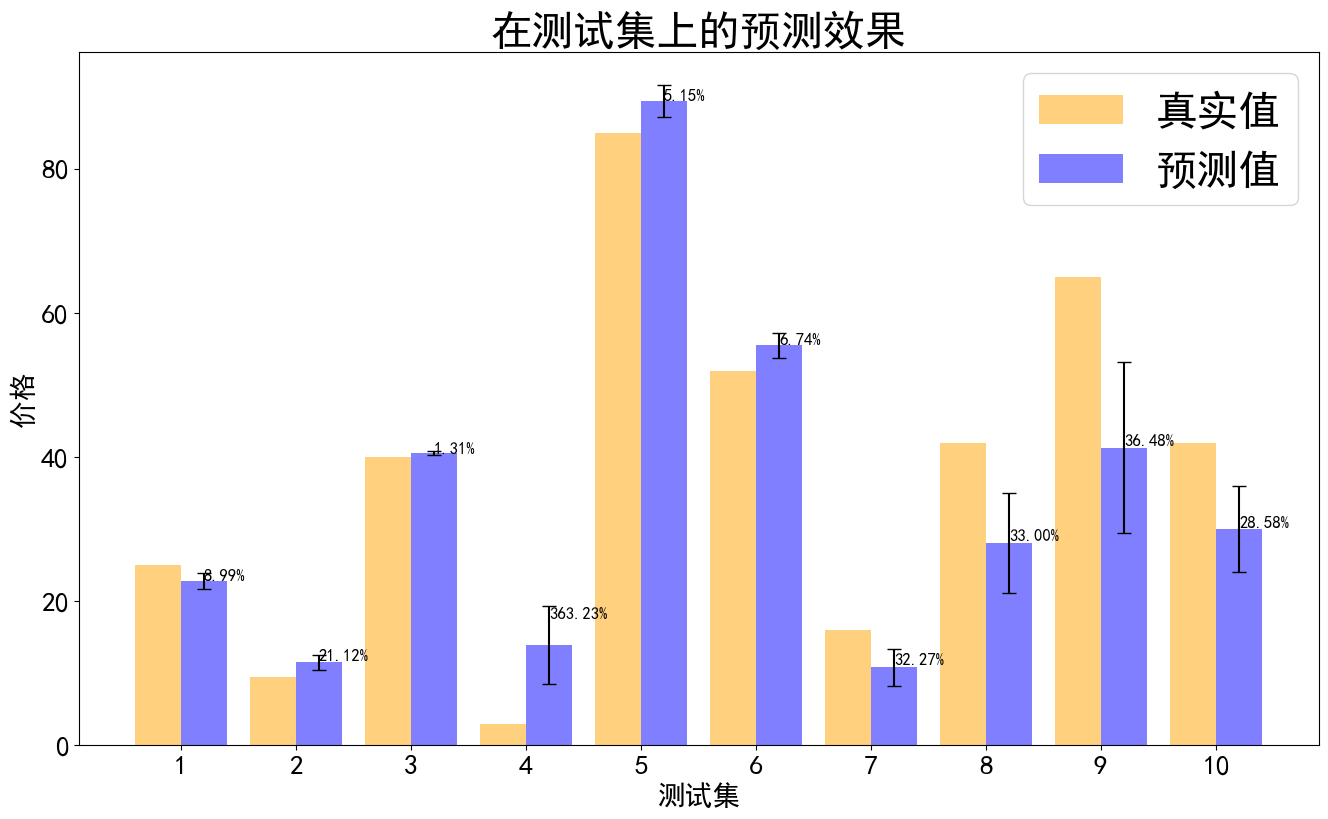

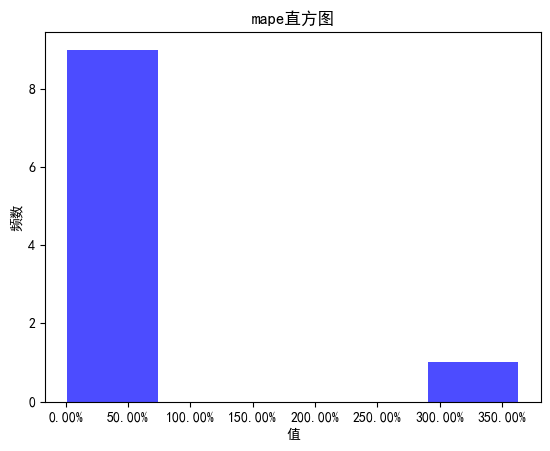

In [19]:
draw_result(lasso_predictions, X_test, y_test)
draw_mapes_hist(y_test, lasso_predictions)

In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

def expert_weighted_ridge_regression(X_train, y_train, X_test, y_test, expert_map):
    # 保证是 DataFrame
    X_train_scaled = pd.DataFrame(X_train).copy()
    X_test_scaled = pd.DataFrame(X_test).copy()

    # 如果你的 y 是 log(price)，这里保持不变
    # 如果 y 不是 log，就不要 np.exp
    y_train = np.array(y_train).copy()
    y_test = np.array(y_test).copy()

    num_cols = X_train.columns.tolist()

    # 1. 标准化
#     scaler = StandardScaler()
#     X_train_scaled = pd.DataFrame(
#         scaler.fit_transform(X_train),
#         columns=num_cols,
#         index=X_train.index
#     )
#     X_test_scaled = pd.DataFrame(
#         scaler.transform(X_test),
#         columns=num_cols,
#         index=X_test.index
#     )

    # 2. 专家权重映射
    weights = {}
    for col in num_cols:
        s = expert_map.get(col, 1.0)
        if s is None or pd.isna(s) or not np.isfinite(s):
            s = 1.0
        s = float(s)
        s = max(1.0, min(5.0, s))
        # 映射到 0.5 ~ 2.5
        weights[col] = 0.3 + (s - 1.0) / 4.0 * 4.7

    # 3. 对特征做专家加权缩放
    for col in num_cols:
        X_train_scaled[col] *= weights[col]
        X_test_scaled[col] *= weights[col]

    # 4. 搜索最佳 alpha
    alphas = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
    best_alpha = None
    best_mse = float('inf')

    for alpha in alphas:
        ridge_model = Ridge(alpha=alpha)
        ridge_model.fit(X_train_scaled, y_train)
        pred_log = ridge_model.predict(X_test_scaled)
        pred = np.exp(pred_log)

        y_true = np.exp(y_test) if np.max(y_test) < 50 else y_test
        mse = mean_squared_error(y_true, pred)

        if mse < best_mse:
            best_mse = mse
            best_alpha = alpha

    print("岭回归模型的最佳正则化参数：", best_alpha)

    # 5. 用最佳 alpha 重新训练
    ridge_model = Ridge(alpha=best_alpha)
    ridge_model.fit(X_train_scaled, y_train)

    pred_log = ridge_model.predict(X_test_scaled)
    pred = np.exp(pred_log)

    y_true = np.exp(y_test) if np.max(y_test) < 50 else y_test

    residuals = y_true - pred
    std_dev = np.std(residuals)

    mse = mean_squared_error(y_true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, pred)
    r2 = r2_score(y_true, pred)
    mape = np.mean(np.abs(pred / y_true - 1))

    print("均方误差 (MSE):", mse)
    print("均方根误差 (RMSE):", rmse)
    print("平均绝对误差 (MAE):", mae)
    print("R^2 得分:", r2)
    print("平均绝对误差百分比:", mape)

    if 'calculate_confidence_intervals' in globals():
        lower_bounds, upper_bounds = calculate_confidence_intervals(pred, std_dev)
        confidence_intervals = list(zip(lower_bounds, upper_bounds))
        print("95% 的置信区间列表:", confidence_intervals)

    return ridge_model, pred, weights, X_train_scaled.columns.tolist()
expert_map = {
    "压力_bar": 5, "出力_kN": 5, "行程_mm": 4, "速度_mm_s": 4,
    "温度_min_°C": 2, "温度_max_°C": 2, "MTBF_小时": 4, "重量_kg": 3,
    "功率_kW": 4, "泄漏_mL_min": 2, "响应时间_ms": 4, "控制方式": 3,
    "适用机型": 2, "材料类型": 4, "密封等级": 4, "液压油类型": 2,
    "流量_L_min": 4, "固有频率_Hz": 3, "阻尼系数": 2, "冗余配置": 3,
    "认证等级": 3, "维护周期_小时": 2, "故障率_10e6_FH": 3,
    "安装方式": 1, "接口类型": 1
}
print(X_test.iloc[0])
ridge_model, ridge_predictions, expert_weights, feature_names = expert_weighted_ridge_regression(
    X_train, y_train, X_test, y_test, expert_map
)
print(X_train.shape)
print(X_test.shape)
coef_df = pd.DataFrame({
    "特征": feature_names,
    "系数": ridge_model.coef_,
    "专家分": [expert_map.get(f, 1) for f in feature_names],
    "专家权重": [expert_weights.get(f, 1.0) for f in feature_names]
})

coef_df["绝对系数"] = coef_df["系数"].abs()
coef_df["修正重要性"] = coef_df["绝对系数"] * coef_df["专家权重"]
coef_df["绝对修正重要性"] = coef_df["修正重要性"].abs()
print("=== 按模型系数排序 ===")
print(coef_df.sort_values(by="绝对系数", ascending=False)[["特征", "系数", "专家分", "专家权重"]])

print("\n=== 按专家修正重要性排序 ===")
print(coef_df.sort_values(by="绝对修正重要性", ascending=False)[["特征", "系数", "专家分", "专家权重", "修正重要性"]])
# ===============================
# 保存完整模型
# ===============================
save_data={
    # 模型
    "model":ridge_model,
    # 专家权重
    "expert_weights":expert_weights,
    # 特征顺序
    "feature_names":feature_names,
    "use_expert_weight":True,
    # 是否log训练
    "log_target":True
}


with open( "ridge_complete.pkl", "wb") as f:
    pickle.dump(save_data,f)


print("\n模型保存完成")


# ===============================
# 重新加载测试
# ===============================


with open("ridge_complete.pkl","rb") as f:
    loaded=pickle.load(f)


loaded_model=loaded["model"]

load_pred=loaded_model.predict(X_test.iloc[[0]])
print(X_test.iloc[[0]])
print("\n重新加载模型预测:")
print(load_pred)

print("价格:",np.exp(load_pred))

压力_bar         0.427430
出力_kN          0.064327
行程_mm          0.127907
速度_mm_s        0.043568
温度_min_°C      0.333333
温度_max_°C      0.230769
MTBF_小时        0.166667
重量_kg          0.096386
功率_kW          0.004445
泄漏_mL_min      0.020000
响应时间_ms        0.418182
控制方式           0.647059
适用机型           0.666667
材料类型           0.500000
密封等级           1.000000
液压油类型          1.000000
流量_L_min       0.044944
固有频率_Hz        0.259259
阻尼系数           0.200000
冗余配置           0.666667
认证等级           0.000000
维护周期_小时        0.117647
故障率_10e6_FH    0.458333
安装方式           0.000000
接口类型           0.000000
Name: 17, dtype: float64
岭回归模型的最佳正则化参数： 1
均方误差 (MSE): 175.367928430847
均方根误差 (RMSE): 13.242655641178887
平均绝对误差 (MAE): 10.292254988075232
R^2 得分: 0.700748813516807
平均绝对误差百分比: 0.6163658130207331
95% 的置信区间列表: [(8.505711978970941, 33.31214514352528), (-1.1180717136401075, 23.68836145091423), (36.063810419924, 60.87024358447834), (2.232172569846167, 27.038605734400505), (78.97128029879562, 103.77771346

In [21]:
ridge_r2, ridge_ci_width, ridge_stability = new_3_indictors(df_X, df_y,X_test, y_test, ridge_predictions, ridge_model, 'Ridge')

R² score: 0.700748813516807
Confidence Interval Width: [47.64359411 47.64359411 47.64359411 47.64359411 47.64359411 47.64359411
 47.64359411 47.64359411 47.64359411 47.64359411]
Model Stability (Std of MAPE): 0.04030009603571243
R² score is acceptable.
Confidence interval width is acceptable.
Model stability is acceptable.


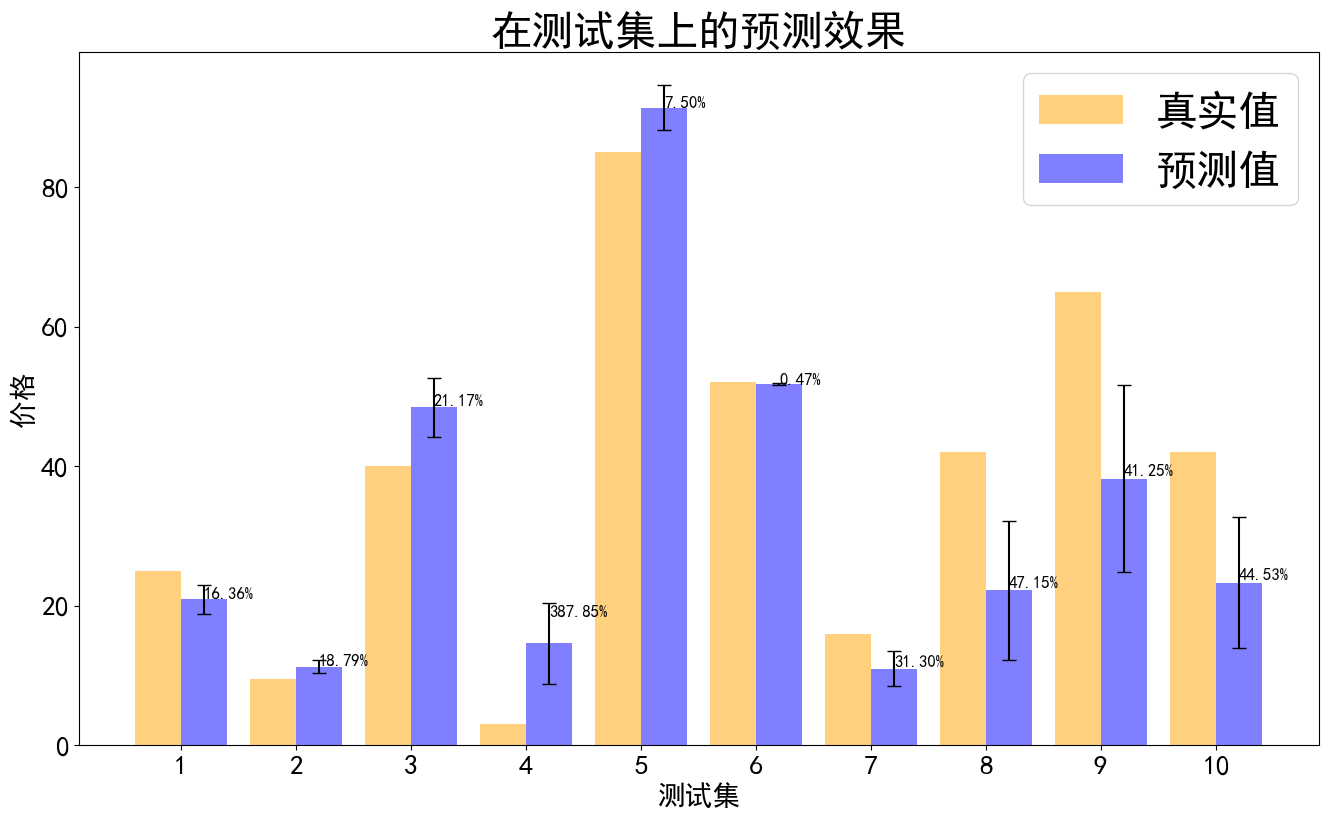

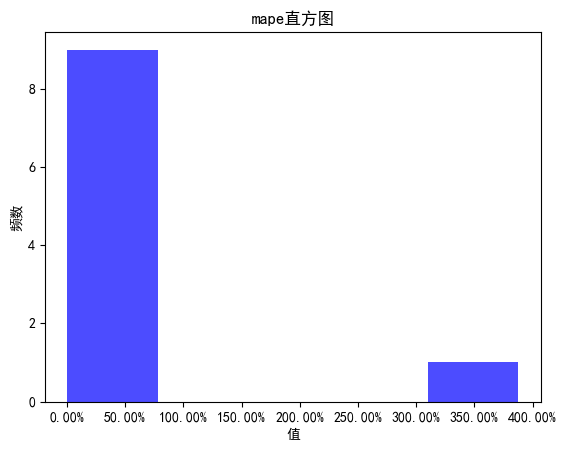

In [22]:
draw_result(ridge_predictions, X_test, y_test)
draw_mapes_hist(y_test, ridge_predictions)

SVR 最好参数组合： {'C': 1, 'epsilon': 0.01, 'gamma': 0.01, 'kernel': 'linear'}
均方误差 (MSE): 193.55155939001008
均方根误差 (RMSE): 13.912280883809458
平均绝对误差 (MAE): 11.261754191336369
R^2 得分: 0.6697199179382872
平均绝对误差百分比: 0.631157374821653
95% 的置信区间列表: [(3.9302006401286977, 30.69039644294603), (-4.008210980777724, 22.75198482203961), (38.02340231009901, 64.78359811291634), (1.3203983815569629, 28.080594184374295), (84.86326407013705, 111.62345987295437), (39.52577763884953, 66.28597344166687), (-4.319666180198281, 22.440529622619053), (17.493408098208462, 44.25360390102579), (22.572367886060334, 49.33256368887767), (8.187005221040033, 34.94720102385737)]
代码运行时间：1.973065秒
(37, 25)
(10, 25)


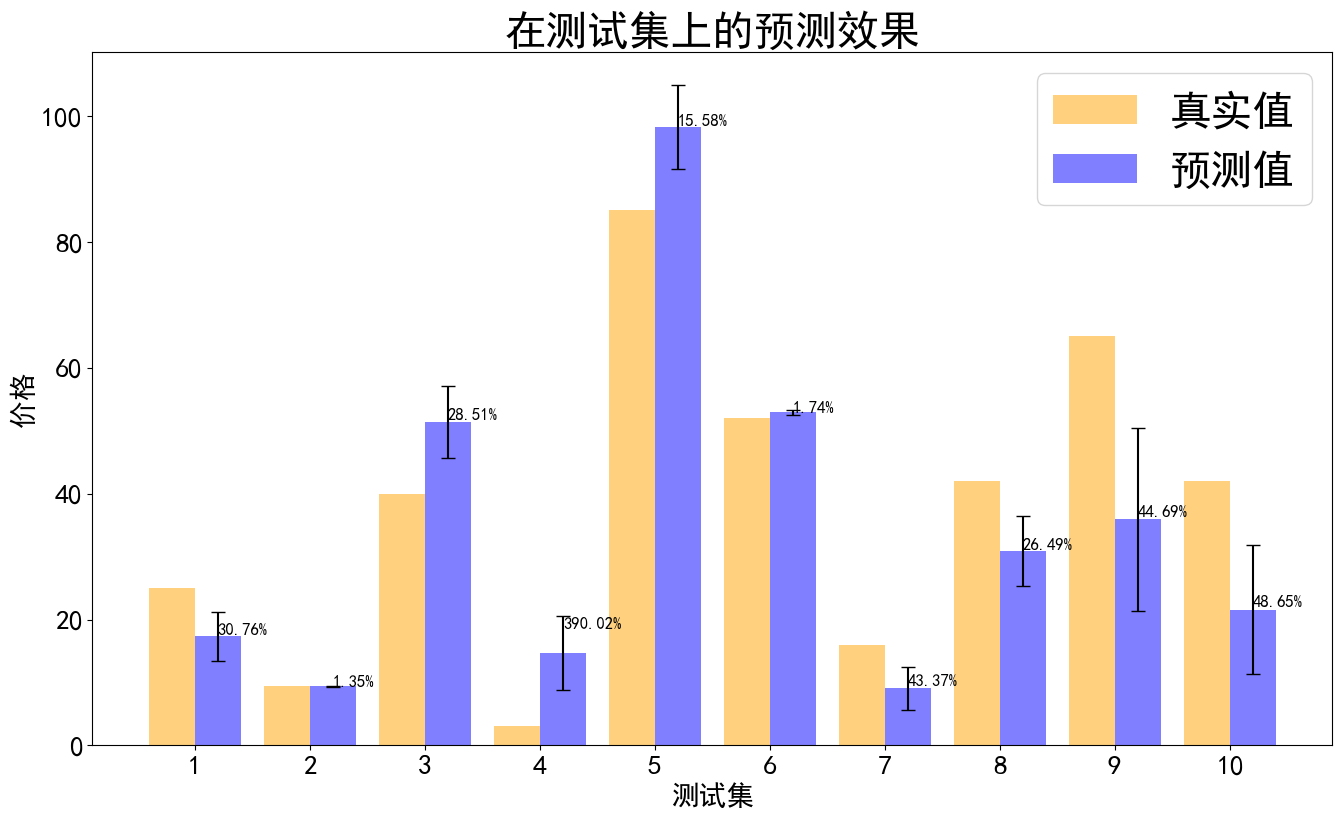

=== 按模型系数排序 ===
             特征        系数  专家分  专家权重
7         重量_kg  1.698910    3   1.5
24         接口类型  0.749882    1   0.5
17      固有频率_Hz -0.732769    3   1.5
9     泄漏_mL_min  0.714629    2   1.0
4     温度_min_°C  0.654528    2   1.0
18         阻尼系数  0.569981    2   1.0
3       速度_mm_s -0.563406    4   2.0
5     温度_max_°C  0.403833    2   1.0
22  故障率_10e6_FH  0.362924    3   1.5
0        压力_bar  0.346578    5   2.5
2         行程_mm  0.344801    4   2.0
6       MTBF_小时  0.246852    4   2.0
11         控制方式 -0.235732    3   1.5
20         认证等级 -0.225975    3   1.5
15        液压油类型 -0.224113    2   1.0
13         材料类型  0.215441    4   2.0
19         冗余配置 -0.213597    3   1.5
23         安装方式  0.208836    1   0.5
12         适用机型  0.151317    2   1.0
8         功率_kW -0.092929    4   2.0
14         密封等级 -0.087997    4   2.0
10      响应时间_ms  0.076350    4   2.0
21      维护周期_小时  0.064082    2   1.0
1         出力_kN -0.025588    5   2.5
16     流量_L_min  0.010997    4   2.0

=== 按专家修正重要性排序 ===
  

In [23]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

def expert_weighted_svr(X_train, y_train, X_test, y_test, expert_map):
    start_time = time.time()

    # 保证是 DataFrame
    X_train_scaled = pd.DataFrame(X_train).copy()
    X_test_scaled = pd.DataFrame(X_test).copy()

    y_train = np.array(y_train).copy()
    y_test = np.array(y_test).copy()

    num_cols = X_train.columns.tolist()

    # 1. 标准化
#     scaler = StandardScaler()
#     X_train_scaled = pd.DataFrame(
#         scaler.fit_transform(X_train),
#         columns=num_cols,
#         index=X_train.index
#     )
#     X_test_scaled = pd.DataFrame(
#         scaler.transform(X_test),
#         columns=num_cols,
#         index=X_test.index
#     )

    # 2. 专家分数 -> 权重
    # 分数 1~5 映射到 0.5~2.5
    expert_weights = {}
    for col in num_cols:
        s = expert_map.get(col, 1.0)
        if s is None or pd.isna(s) or not np.isfinite(s):
            s = 1.0
        s = float(s)
        s = max(1.0, min(5.0, s))
        expert_weights[col] = 0.5 + (s - 1.0) / 4.0 * 2.0

    # 3. 对特征做专家加权缩放
    for col in num_cols:
        X_train_scaled[col] *= expert_weights[col]
        X_test_scaled[col] *= expert_weights[col]

    # 4. 网格搜索参数
    svr = SVR()
    param_grid = {
        'kernel': ['linear'],
        'C': [1, 10, 100],
        'epsilon': [0.01, 0.1,0.2],
        'gamma': [0.01, 0.1]
    }

    grid_svr = GridSearchCV(
        svr,
        param_grid=param_grid,
        cv=10,
        scoring='neg_mean_absolute_error'
    )
    grid_svr.fit(X_train_scaled, y_train)

    svr_model = grid_svr.best_estimator_
    print("SVR 最好参数组合：", grid_svr.best_params_)

    # 5. 预测
    pred_log = svr_model.predict(X_test_scaled)
    pred = np.exp(pred_log)

    # 如果 y_test 是 log 值，则还原
    y_true = np.exp(y_test) if np.max(y_test) < 50 else y_test

    # 6. 模型分析
    residuals = y_true - pred
    std_dev = np.std(residuals)

    mse = mean_squared_error(y_true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, pred)
    r2 = r2_score(y_true, pred)
    mape = np.mean(np.abs(pred / y_true - 1))

    print("均方误差 (MSE):", mse)
    print("均方根误差 (RMSE):", rmse)
    print("平均绝对误差 (MAE):", mae)
    print("R^2 得分:", r2)
    print("平均绝对误差百分比:", mape)

    if 'calculate_confidence_intervals' in globals():
        lower_bounds, upper_bounds = calculate_confidence_intervals(pred, std_dev)
        confidence_intervals = list(zip(lower_bounds, upper_bounds))
        print("95% 的置信区间列表:", confidence_intervals)

    elapsed_time = time.time() - start_time
    print(f"代码运行时间：{elapsed_time:.6f}秒")

    return svr_model, pred, expert_weights, num_cols
expert_map = {
    "压力_bar": 5, "出力_kN": 5, "行程_mm": 4, "速度_mm_s": 4,
    "温度_min_°C": 2, "温度_max_°C": 2, "MTBF_小时": 4, "重量_kg": 3,
    "功率_kW": 4, "泄漏_mL_min": 2, "响应时间_ms": 4, "控制方式": 3,
    "适用机型": 2, "材料类型": 4, "密封等级": 4, "液压油类型": 2,
    "流量_L_min": 4, "固有频率_Hz": 3, "阻尼系数": 2, "冗余配置": 3,
    "认证等级": 3, "维护周期_小时": 2, "故障率_10e6_FH": 3,
    "安装方式": 1, "接口类型": 1
}
svr_model, grid_svr_pred, expert_weights, feature_names = expert_weighted_svr(
    X_train, y_train, X_test, y_test, expert_map
)
print(X_train.shape)
print(X_test.shape)
draw_result(grid_svr_pred, X_test, y_test)


coef_df = pd.DataFrame({
    "特征": feature_names,
    "系数": svr_model.coef_.ravel(),
    "专家分": [expert_map.get(f, 1) for f in feature_names],
    "专家权重": [expert_weights.get(f, 1.0) for f in feature_names]
})


coef_df["绝对系数"] = coef_df["系数"].abs()
coef_df["修正重要性"] = coef_df["绝对系数"] * coef_df["专家权重"]
coef_df["绝对修正重要性"] = coef_df["修正重要性"].abs()
print("=== 按模型系数排序 ===")
print(coef_df.sort_values(by="绝对系数", ascending=False)[["特征", "系数", "专家分", "专家权重"]])

print("\n=== 按专家修正重要性排序 ===")
print(coef_df.sort_values(by="绝对修正重要性", ascending=False)[["特征", "系数", "专家分", "专家权重", "修正重要性"]])
# ===============================
# 保存完整模型
# ===============================
save_data={
    # 模型
    "model":svr_model,
    # 专家权重
    "expert_weights":expert_weights,
    # 特征顺序
    "feature_names":feature_names,
    "use_expert_weight":True,
    # 是否log训练
    "log_target":True
}


with open( "svr_complete.pkl", "wb") as f:
    pickle.dump(save_data,f)


print("\n模型保存完成")


# ===============================
# 重新加载测试
# ===============================


with open("svr_complete.pkl","rb") as f:
    loaded=pickle.load(f)


loaded_model=loaded["model"]

load_pred=loaded_model.predict(X_test.iloc[[0]])
print(X_test.iloc[[0]])
print("\n重新加载模型预测:")
print(load_pred)

print("价格:",np.exp(load_pred))

In [24]:
svr_r2, svr_ci_width, svr_stability = new_3_indictors(df_X, df_y,X_test, y_test, grid_svr_pred, svr_model, 'SVR')

R² score: 0.6697199179382872
Confidence Interval Width: [52.28780969 52.28780969 52.28780969 52.28780969 52.28780969 52.28780969
 52.28780969 52.28780969 52.28780969 52.28780969]
Model Stability (Std of MAPE): 1.2360170104608372
R² score is acceptable.
Confidence interval width is acceptable.
Model stability is acceptable.


最好参数 {'learning_rate': 0.1, 'max_depth': 9, 'min_samples_split': 10, 'n_estimators': 100, 'subsample': 0.9}
均方误差 (MSE): 47.15398896942694
均方根误差 (RMSE): 6.866876216259249
平均绝对误差 (MAE): 4.286430830643564
R^2 得分: 0.9195355315377363
95% 的置信区间列表: [(18.992233156118044, 30.84453227627365), (3.0767413950540536, 14.92904051520966), (30.366266466654317, 42.21856558680992), (-0.452363389985484, 11.399935730170123), (69.09281701155741, 80.94511613171302), (43.03141805878473, 54.88371717894034), (8.883483029575759, 20.735782149731364), (34.08781853203827, 45.94011765219388), (40.78231006431716, 52.634609184472765), (37.68665677098769, 49.538955891143296)]
平均绝对误差百分比: 0.15903020876584023
(37, 25)
(10, 25)


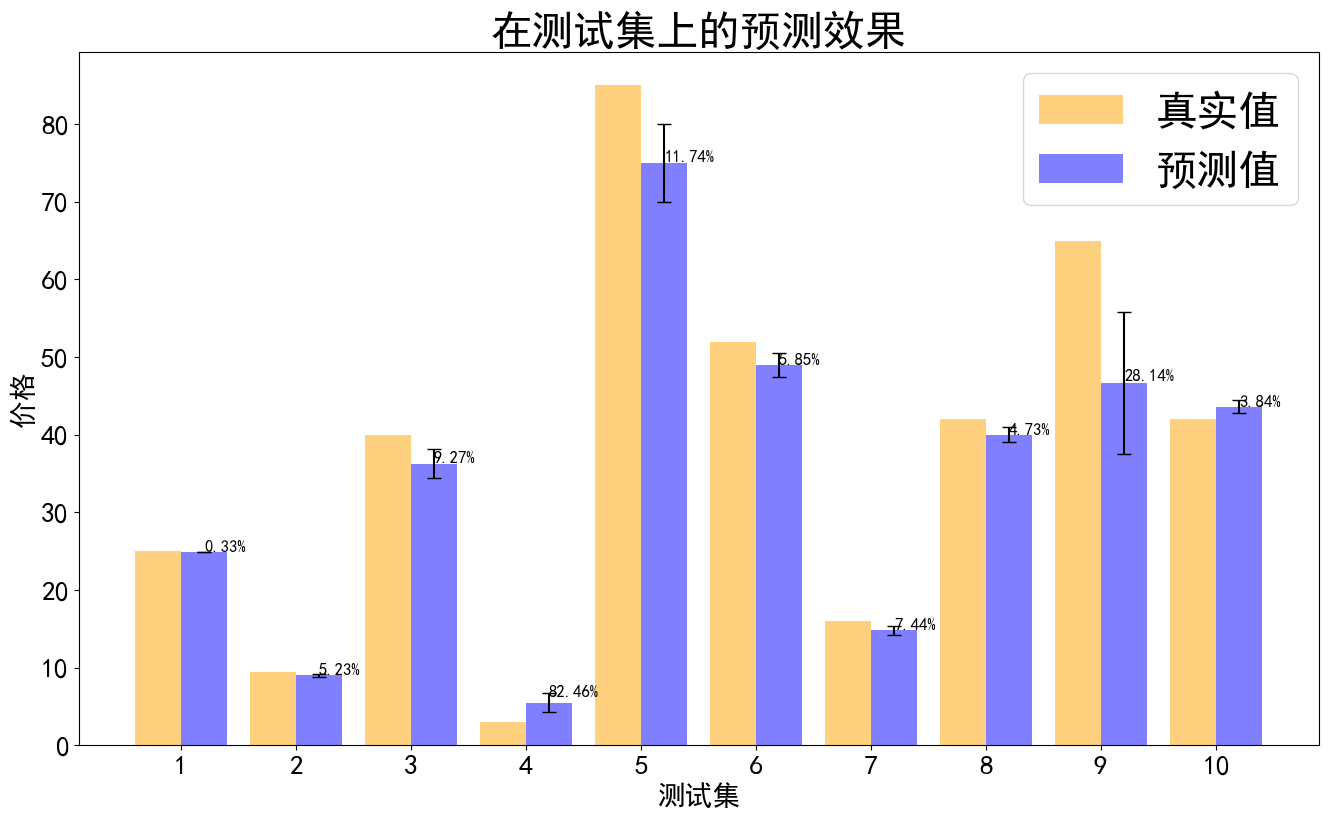


模型保存完成
     压力_bar     出力_kN     行程_mm   速度_mm_s  温度_min_°C  温度_max_°C   MTBF_小时  \
17  0.42743  0.064327  0.127907  0.043568   0.333333   0.230769  0.166667   

       重量_kg     功率_kW  泄漏_mL_min  ...  液压油类型  流量_L_min   固有频率_Hz  阻尼系数  \
17  0.096386  0.004445       0.02  ...    1.0  0.044944  0.259259   0.2   

        冗余配置  认证等级   维护周期_小时  故障率_10e6_FH  安装方式  接口类型  
17  0.666667   0.0  0.117647     0.458333   0.0   0.0  

[1 rows x 25 columns]

重新加载模型预测:
[3.21560579]
价格: [24.91838272]


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False
def gbdt(X_train, y_train, X_test, y_test):
    # 定义多组参数组合，包括 loss 参数
    param_grid = {
        'min_samples_split': [2,4,6,8,10],   # 内部节点最小样本数
        #'min_samples_leaf': [1,3,5,7,9],     # 叶子节点最小样本数
        #'loss': ['huber'],  # 损失函数选项
        'max_depth': [3,5,7,9],
        'n_estimators': [100,300],
        'learning_rate': [0.1],
        'subsample':[0.7,0.9,1]
    }

    # 创建GradientBoostingRegressor模型
    gbdt = GradientBoostingRegressor()

    # 使用GridSearchCV进行参数搜索和交叉验证
    grid_gbdt = GridSearchCV(estimator=gbdt, param_grid=param_grid, cv=10, scoring='neg_mean_absolute_error',n_jobs=6)
    grid_gbdt.fit(X_train, y_train)
    # 输出测试集上的预测结果
    gbdt_model = grid_gbdt.best_estimator_   
    print("最好参数",grid_gbdt.best_params_)

    grid_gbdt_pred = gbdt_model.predict(X_test)
    grid_gbdt_pred = np.exp(grid_gbdt_pred)

    # 模型分析

    # 计算每个测试样本的残差
    residuals = y_test - grid_gbdt_pred

    # 计算残差的标准差
    std_dev = np.std(residuals)

    model5_mse = mean_squared_error(y_test, grid_gbdt_pred)
    print("均方误差 (MSE):", model5_mse)
    model5_rmse = np.sqrt(model5_mse)
    print("均方根误差 (RMSE):", model5_rmse)
    model5_mae = mean_absolute_error(y_test, grid_gbdt_pred)
    print("平均绝对误差 (MAE):", model5_mae)
    model5_r2 = r2_score(y_test, grid_gbdt_pred)
    print("R^2 得分:", model5_r2)
    lower_bounds, upper_bounds = calculate_confidence_intervals(grid_gbdt_pred, std_dev)
    confidence_intervals = list(zip(lower_bounds, upper_bounds))
    print("95% 的置信区间列表:", confidence_intervals)
    GBDTbili=abs(grid_gbdt_pred/y_test-1)
    print("平均绝对误差百分比:",GBDTbili.mean())
    return gbdt_model, grid_gbdt_pred
gbdt_model, grid_gbdt_pred = gbdt(X_train, y_train, X_test, y_test)
print(X_train.shape)
print(X_test.shape)
draw_result(grid_gbdt_pred, X_test, y_test)
# ===============================
# 保存完整模型
# ===============================
save_data={
    # 模型
    "model":gbdt_model,
    # 专家权重
    "expert_weights":expert_weights,
    # 特征顺序
    "feature_names":feature_names,
    "use_expert_weight":False,
    # 是否log训练
    "log_target":True
}


with open( "gbdt_complete.pkl", "wb") as f:
    pickle.dump(save_data,f)


print("\n模型保存完成")


# ===============================
# 重新加载测试
# ===============================


with open("gbdt_complete.pkl","rb") as f:
    loaded=pickle.load(f)


loaded_model=loaded["model"]

load_pred=loaded_model.predict(X_test.iloc[[0]])
print(X_test.iloc[[0]])
print("\n重新加载模型预测:")
print(load_pred)

print("价格:",np.exp(load_pred))

In [26]:
gbdt_r2, gbdt_ci_width, gbdt_stability = new_3_indictors(df_X, df_y,X_test, y_test, grid_gbdt_pred, gbdt_model, 'GBDT')

R² score: 0.9195355315377363
Confidence Interval Width: [40.44083186 40.44083186 40.44083186 40.44083186 40.44083186 40.44083186
 40.44083186 40.44083186 40.44083186 40.44083186]
Model Stability (Std of MAPE): 0.14627616934772547
R² score is acceptable.
Confidence interval width is acceptable.
Model stability is acceptable.


(37, 25)
(10, 25)


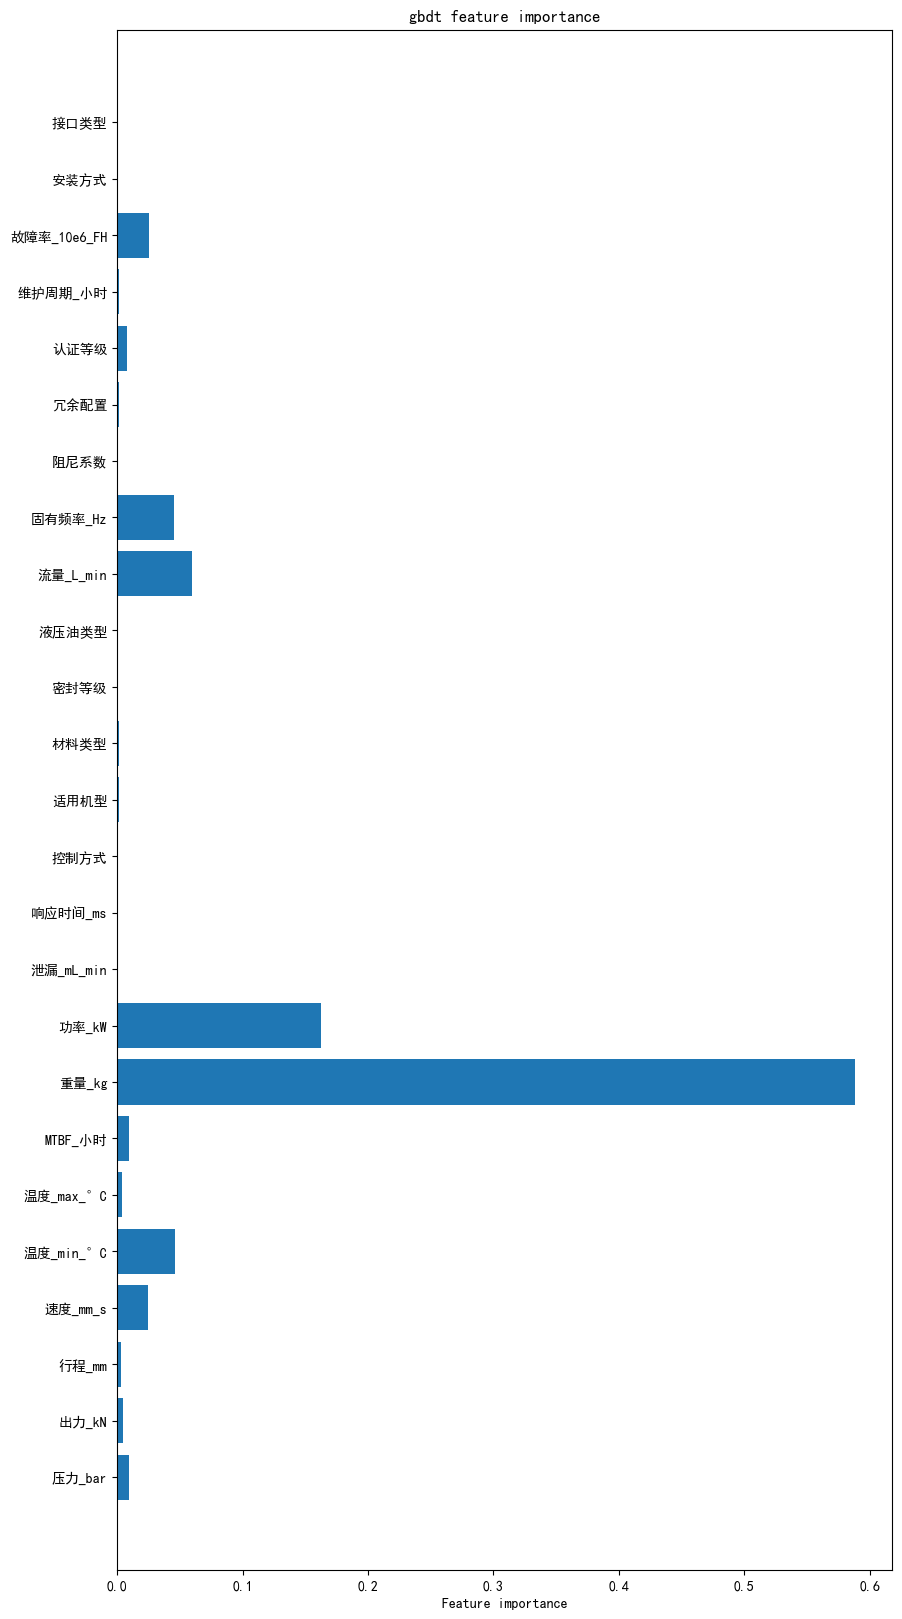

[9.46434602e-03 4.85946217e-03 2.98294455e-03 2.47261077e-02
 4.59719823e-02 4.15165997e-03 9.53320792e-03 5.88490465e-01
 1.62312766e-01 4.25351629e-05 7.21310697e-04 4.79624386e-04
 1.54794589e-03 1.23375540e-03 7.69542800e-04 0.00000000e+00
 5.93352607e-02 4.54125754e-02 1.36539566e-04 1.56314563e-03
 8.20360102e-03 1.14584128e-03 2.54767725e-02 1.04358382e-03
 3.95024319e-04]


In [27]:
gbdt_importance = gbdt_model.feature_importances_
plt.figure(figsize=(10,20))
print(X_train.shape)
print(X_test.shape)
plt.barh(range(len(gbdt_importance)),gbdt_importance,tick_label=X_train.columns)
plt.xlabel('Feature importance')
plt.title('gbdt feature importance')
plt.show()
print(gbdt_importance)

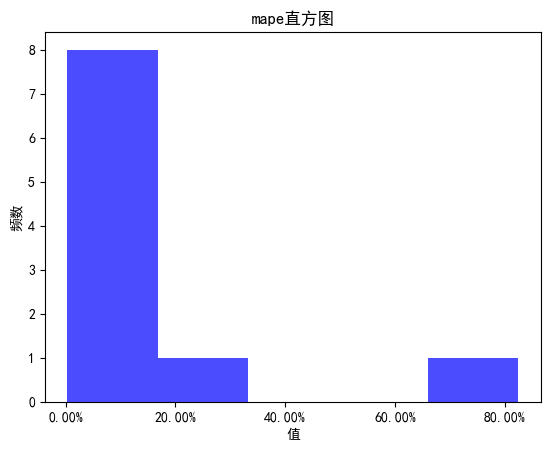

In [28]:
draw_mapes_hist(y_test, grid_gbdt_pred)

最好 {'max_depth': 20, 'min_samples_split': 4, 'n_estimators': 100}
均方误差 (MSE): 130.64167235577554
均方根误差 (RMSE): 11.42985880734209
平均绝对误差 (MAE): 7.116890349391722
R^2 得分: 0.777070552144712
95% 的置信区间列表: [(12.571538624131833, 33.86970691858332), (2.122491579279366, 23.420659873730852), (27.73210701380919, 49.03027530826068), (3.9040476665420254, 25.202215960993513), (71.63502436396774, 92.93319265841924), (38.80691707555934, 60.105085370010826), (4.207103963997582, 25.505272258449068), (26.117449135213647, 47.41561742966513), (22.27948420217586, 43.577652496627344), (22.1135064896945, 43.41167478414599)]
平均绝对误差百分比: 0.5297379910701936
(37, 25)
(10, 25)


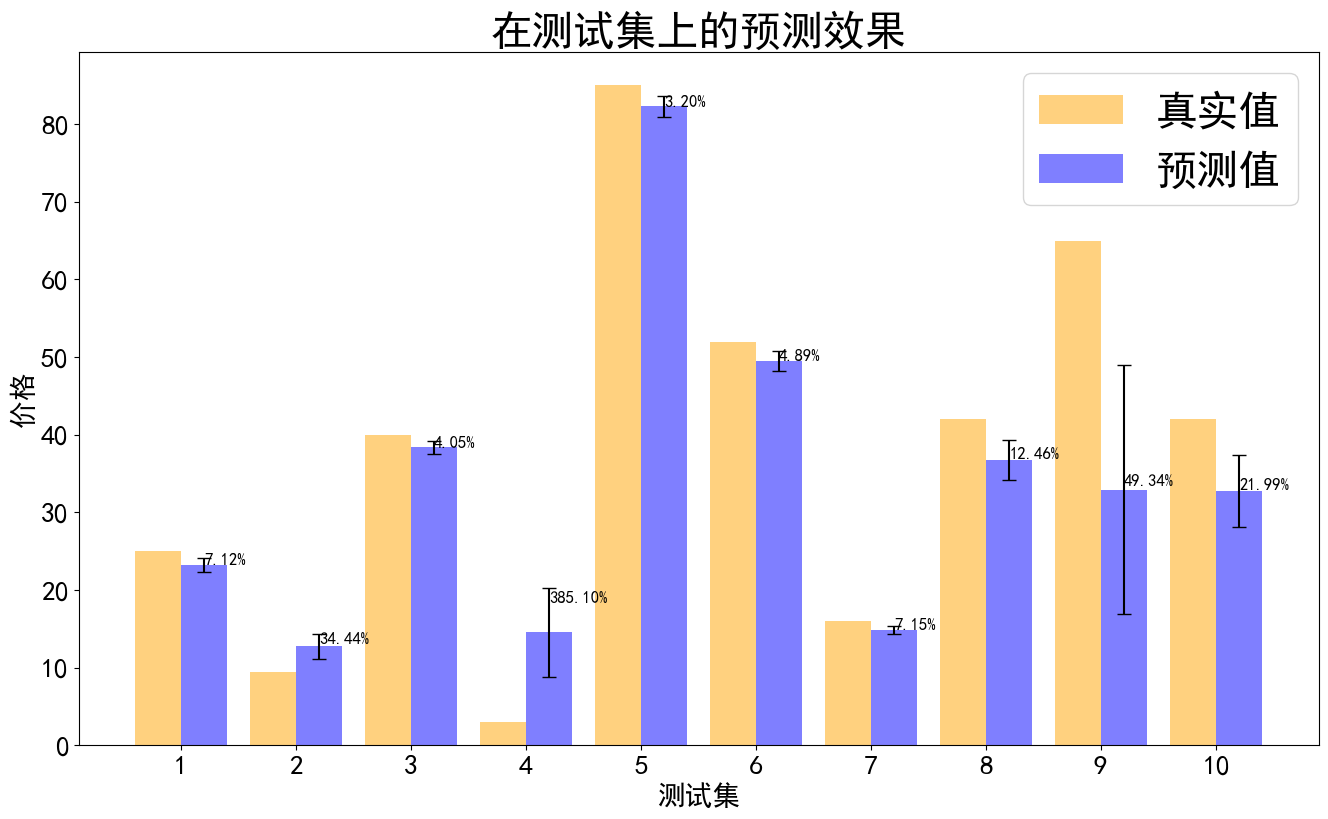

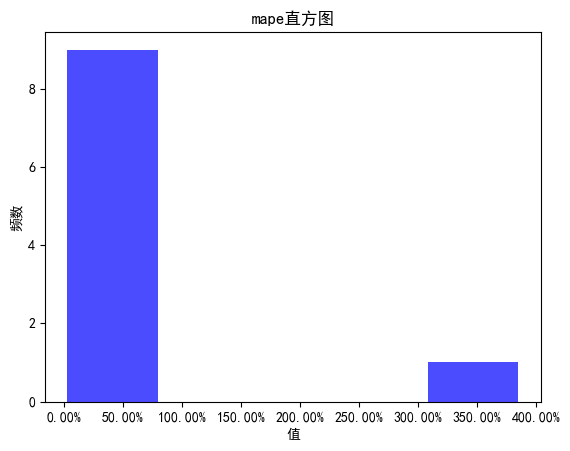


模型保存完成
     压力_bar     出力_kN     行程_mm   速度_mm_s  温度_min_°C  温度_max_°C   MTBF_小时  \
17  0.42743  0.064327  0.127907  0.043568   0.333333   0.230769  0.166667   

       重量_kg     功率_kW  泄漏_mL_min  ...  液压油类型  流量_L_min   固有频率_Hz  阻尼系数  \
17  0.096386  0.004445       0.02  ...    1.0  0.044944  0.259259   0.2   

        冗余配置  认证等级   维护周期_小时  故障率_10e6_FH  安装方式  接口类型  
17  0.666667   0.0  0.117647     0.458333   0.0   0.0  

[1 rows x 25 columns]

重新加载模型预测:
[3.1450408]
价格: [23.22062277]


In [29]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor
import matplotlib.pyplot as plt
def et(X_train, y_train, X_test, y_test):
    # 超参数搜索范围
    max_depth_options = [10, 20, 30]  # 不同的最大深度值
    n_estimators_options = [100, 300]  # 不同的树的数量
    min_samples_split = [4, 6, 8, 10]  # 不同的最小样本拆分值
    #min_samples_leaf = [1, 3, 5, 7, 9]

    parameters = {
        'max_depth': max_depth_options,
        'n_estimators': n_estimators_options,
        'min_samples_split': min_samples_split,
        #'min_samples_leaf': min_samples_leaf
    }

    # 创建GridSearchCV对象
    grid_et = GridSearchCV(estimator=ExtraTreesRegressor(), param_grid=parameters, cv=10, scoring='neg_mean_absolute_error', n_jobs=6)
    grid_et.fit(X_train, y_train)
    # 获取最佳参数组合
    best_params = grid_et.best_params_
    # 创建 ExtraTreesRegressor 模型
    et_model = ExtraTreesRegressor(max_depth=best_params['max_depth'], 
                                   n_estimators=best_params['n_estimators'], 
                                   min_samples_split=best_params['min_samples_split'],
                                   #min_samples_leaf=best_params['min_samples_leaf']
                                  )

    # 拟合 ExtraTreesRegressor 模型
    et_model.fit(X_train, y_train)
    print("最好",best_params)
    # 使用模型进行预测
    grid_et_pred = et_model.predict(X_test)
    grid_et_pred = np.exp(grid_et_pred)

    # 模型分析
    # 计算每个测试样本的残差
    residuals = y_test - grid_et_pred

    # 计算残差的标准差
    std_dev = np.std(residuals)
    model6_mse = mean_squared_error(y_test, grid_et_pred)
    print("均方误差 (MSE):", model6_mse)
    model6_rmse = np.sqrt(model6_mse)
    print("均方根误差 (RMSE):", model6_rmse)
    model6_mae = mean_absolute_error(y_test, grid_et_pred)
    print("平均绝对误差 (MAE):", model6_mae)
    model6_r2 = r2_score(y_test, grid_et_pred)
    print("R^2 得分:", model6_r2)
    lower_bounds, upper_bounds = calculate_confidence_intervals(grid_et_pred, std_dev)
    confidence_intervals = list(zip(lower_bounds, upper_bounds))
    print("95% 的置信区间列表:", confidence_intervals)
    ETlibi=abs(grid_et_pred/y_test-1)
    print("平均绝对误差百分比:",ETlibi.mean())
    return et_model, grid_et_pred
et_model, grid_et_pred = et(X_train, y_train, X_test, y_test)
print(X_train.shape)
print(X_test.shape)
draw_result(grid_et_pred, X_test, y_test)
draw_mapes_hist(y_test, grid_et_pred)
# ===============================
# 保存完整模型
# ===============================
save_data={
    # 模型
    "model":et_model,
    # 专家权重
    "expert_weights":expert_weights,
    # 特征顺序
    "feature_names":feature_names,
    "use_expert_weight":False,
    # 是否log训练
    "log_target":True
}


with open( "et_complete.pkl", "wb") as f:
    pickle.dump(save_data,f)


print("\n模型保存完成")


# ===============================
# 重新加载测试
# ===============================


with open("et_complete.pkl","rb") as f:
    loaded=pickle.load(f)


loaded_model=loaded["model"]

load_pred=loaded_model.predict(X_test.iloc[[0]])
print(X_test.iloc[[0]])
print("\n重新加载模型预测:")
print(load_pred)

print("价格:",np.exp(load_pred))

In [30]:
et_r2, et_ci_width, et_stability = new_3_indictors(df_X, df_y,X_test, y_test, grid_et_pred, et_model, 'ET')

R² score: 0.777070552144712
Confidence Interval Width: [39.55184017 39.55184017 39.55184017 39.55184017 39.55184017 39.55184017
 39.55184017 39.55184017 39.55184017 39.55184017]
Model Stability (Std of MAPE): 0.20127323875930808
R² score is acceptable.
Confidence interval width is acceptable.
Model stability is acceptable.


(37, 25)
(10, 25)


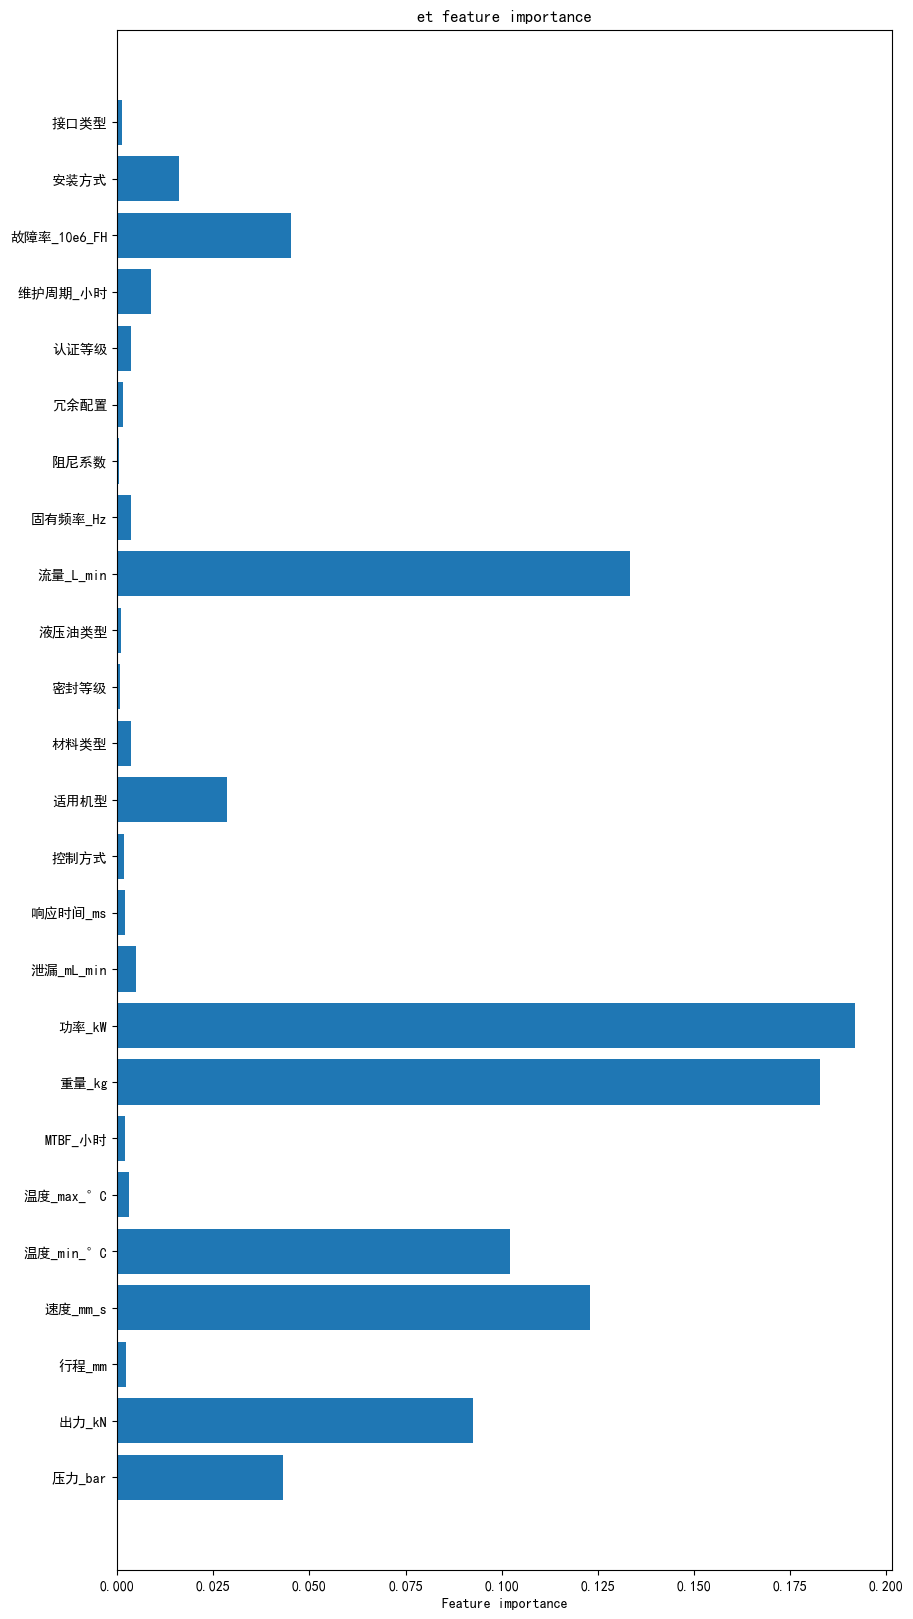

[0.04308301 0.09263972 0.00222366 0.1229923  0.10218778 0.00320186
 0.00216605 0.18265602 0.1918662  0.00484095 0.00217861 0.00171885
 0.02857285 0.00358077 0.00078118 0.00114366 0.13326769 0.00350676
 0.000461   0.00144238 0.00363945 0.00891484 0.04533498 0.01620859
 0.00139084]


In [31]:
et_importance = et_model.feature_importances_
plt.figure(figsize=(10,20))
print(X_train.shape)
print(X_test.shape)
plt.barh(range(len(et_importance)),et_importance,tick_label=X_train.columns)
plt.xlabel('Feature importance')
plt.title('et feature importance')
plt.show()
print(et_importance)


最好参数: {'lambda_expert': 0.8, 'max_depth': 6, 'min_gain_split': 0.05, 'min_samples_leaf': 1}
均方误差 (MSE): 41.183672878180204
均方根误差 (RMSE): 6.417450652570708
平均绝对误差 (MAE): 4.70124788217206
R^2 得分: 0.9297233930810161
平均绝对误差百分比: 0.19297933669902068
95% 的置信区间列表: [(15.706259353306617, 26.246094573499438), (2.93008238990359, 13.46991761009641), (29.71579375897539, 40.25562897916821), (0.20730796495525095, 10.747143185148069), (82.4481423585758, 92.98797757876862), (43.42785500959511, 53.96769022978793), (9.389054478685964, 19.92888969887878), (34.73008238990359, 45.26991761009641), (43.42785500959511, 53.96769022978793), (28.196483451266612, 38.73631867145943)]


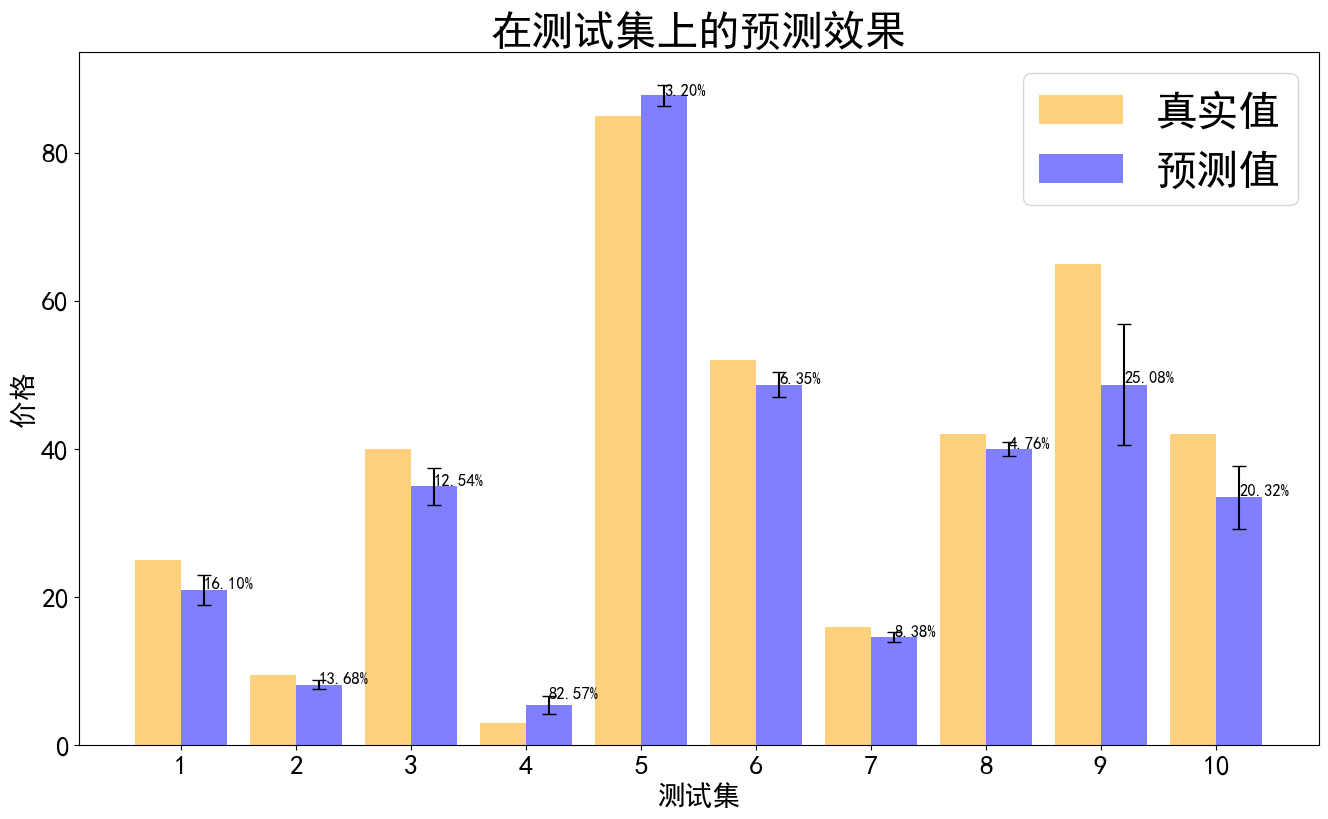

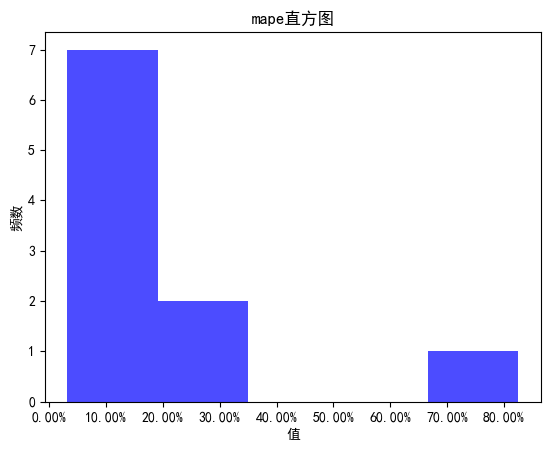

[4.5e+00 8.0e+00 1.2e+01 8.0e+00 3.0e+01 7.0e+01 8.0e+03 4.8e-01 2.0e-03
 0.0e+00 5.0e+00 1.0e+00 1.0e+00 1.0e+00 1.0e+00 1.0e+00 5.0e+00 1.5e+01
 5.0e-01 1.0e+00 1.0e+00 3.0e+03 1.0e-01 1.0e+00 1.0e+00]
[3.80e+02 3.50e+02 7.00e+02 9.72e+02 6.00e+01 2.00e+02 5.00e+04 1.20e+02
 3.37e+02 5.00e+02 2.80e+02 1.80e+01 1.30e+01 7.00e+00 4.00e+00 3.00e+00
 4.50e+02 1.50e+02 1.00e+00 4.00e+00 5.00e+00 2.00e+04 2.50e+00 6.00e+00
 4.00e+00]
Rule 1

IF
    重量_kg ≤ 13.50
AND 出力_kN ≤ 133.50
AND MTBF_小时 ≤ 18000.00
AND 流量_L_min ≤ 14.00

THEN
    历史成交价格范围：34.00 ～ 36.00 万元
    样本数：2

Rule 2

IF
    重量_kg ≤ 13.50
AND 出力_kN ≤ 133.50
AND MTBF_小时 ≤ 18000.00
AND 流量_L_min > 14.00
AND 响应时间_ms ≤ 65.00

THEN
    历史成交价格范围：24.00 ～ 28.00 万元
    样本数：3

Rule 3

IF
    重量_kg ≤ 13.50
AND 出力_kN ≤ 133.50
AND MTBF_小时 ≤ 18000.00
AND 流量_L_min > 14.00
AND 响应时间_ms > 65.00

THEN
    历史成交价格范围：20.00 ～ 22.00 万元
    样本数：2

Rule 4

IF
    重量_kg ≤ 13.50
AND 出力_kN ≤ 133.50
AND MTBF_小时 > 18000.00
AND 功率_kW ≤ 0.03

THEN
    历史成交价格范围：8.

In [32]:
#专家重要度目前最满意
import numpy as np
import pandas as pd
from dataclasses import dataclass
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import json
from services.price_service.expert_tree import TreeNode, ExpertWeightedTreeRegressor


def rf_expert_split(X_train, y_train, X_test, y_test, expert_map):
    parameters = {
        'max_depth': [5,6,7,8,10],
        'min_samples_leaf': [1],
        'lambda_expert': [0.5, 0.8],
        'min_gain_split': [0.05,0.1,0.15]
    }

    grid_rf = GridSearchCV(
        estimator=ExpertWeightedTreeRegressor(expert_map=expert_map),
        param_grid=parameters,
        cv=LeaveOneOut(),
        scoring='neg_mean_absolute_error',
        n_jobs=1,
        error_score='raise'
    )

    grid_rf.fit(X_train, y_train)

    best_params = grid_rf.best_params_
    print("最好参数:", best_params)

    rf_model = ExpertWeightedTreeRegressor(
        max_depth=best_params['max_depth'],
        min_samples_leaf=best_params['min_samples_leaf'],
        lambda_expert=best_params['lambda_expert'],
        min_gain_split=best_params['min_gain_split'],
        expert_map=expert_map
    )

    rf_model.fit(X_train, y_train)
    pred = rf_model.predict(X_test)

    pred = np.exp(pred)
    y_test_real = np.exp(y_test) if np.max(y_test) < 50 else y_test

    residuals = y_test_real - pred
    std_dev = np.std(residuals)

    mse = mean_squared_error(y_test_real, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_real, pred)
    r2 = r2_score(y_test_real, pred)
    mape = np.mean(np.abs(pred / y_test_real - 1))

    print("均方误差 (MSE):", mse)
    print("均方根误差 (RMSE):", rmse)
    print("平均绝对误差 (MAE):", mae)
    print("R^2 得分:", r2)
    print("平均绝对误差百分比:", mape)

    if 'calculate_confidence_intervals' in globals():
        lower_bounds, upper_bounds = calculate_confidence_intervals(pred, std_dev)
        confidence_intervals = list(zip(lower_bounds, upper_bounds))
        print("95% 的置信区间列表:", confidence_intervals)

    return rf_model, pred
def print_cart_rules(node, scaler=None, feature_names=None, save_path=None):
    rule_id = [1]
    rules = []

    def dfs(node, conditions):
        if node is None:
            return

        if node.is_leaf or node.feature is None:
            print("=" * 60)
            print(f"Rule {rule_id[0]}\n")
            print("IF")
            for i, cond in enumerate(conditions):
                print(("    " if i == 0 else "AND ") + cond)
            print("\nTHEN")
            print(f"    历史成交价格范围：{node.min_price:.2f} ～ {node.max_price:.2f} 万元")
            print(f"    样本数：{node.sample_num}\n")

            # 额外：收集到 JSON 结构
            rules.append({
                "rule_id": rule_id[0],
                "conditions": conditions.copy(),
                "price_range": {
                    "min": float(node.min_price),
                    "max": float(node.max_price),
                    "unit": "万元"
                },
                "sample_count": int(node.sample_num)
            })

            rule_id[0] += 1
            return

        threshold = node.threshold

        if scaler is not None:
            idx = feature_names.index(node.feature)
            threshold = (
                threshold - scaler.min_[idx]
            ) / scaler.scale_[idx]

        dfs(node.left, conditions + [f"{node.feature} ≤ {threshold:.2f}"])
        dfs(node.right, conditions + [f"{node.feature} > {threshold:.2f}"])

    dfs(node, [])

    # 如果提供了保存路径，就保存 JSON
    if save_path is not None:
        with open(save_path, "w", encoding="utf-8") as f:
            json.dump(rules, f, ensure_ascii=False, indent=2)

    return rules
expert_map = {
    "压力_bar": 5, "出力_kN": 5, "行程_mm": 4, "速度_mm_s": 4,
    "温度_min_°C": 2, "温度_max_°C": 2, "MTBF_小时": 4, "重量_kg": 3,
    "功率_kW": 4, "泄漏_mL_min": 2, "响应时间_ms": 4, "控制方式": 3,
    "适用机型": 2, "材料类型": 4, "密封等级": 4, "液压油类型": 2,
    "流量_L_min": 4, "固有频率_Hz": 3, "阻尼系数": 2, "冗余配置": 3,
    "认证等级": 3, "维护周期_小时": 2, "故障率_10e6_FH": 3,
    "安装方式": 1, "接口类型": 1
}
rf_model, grid_rf_pred = rf_expert_split(X_train, y_train, X_test, y_test, expert_map)
draw_result(grid_rf_pred, X_test, y_test)
draw_mapes_hist(y_test, grid_rf_pred)
print(scaler.data_min_)
print(scaler.data_max_)
'''print("规则树如下：")
print_cart_rules(
    rf_model.root_,
    scaler=scaler,
    feature_names=X_train.columns.tolist()
   
)'''
rules = print_cart_rules(
    rf_model.root_,
    scaler=scaler,
    feature_names=X_train.columns.tolist(),
    save_path="rules.json"
)
# ===============================
# 保存完整模型
# ===============================
save_data={
    # 模型
    "model":rf_model,
    # 专家权重
    "expert_weights":expert_weights,
    # 特征顺序
    "feature_names":feature_names,
    "use_expert_weight":False,
    # 是否log训练
    "log_target":True
}


with open( "rf_complete.pkl", "wb") as f:
    pickle.dump(save_data,f)


print("\n模型保存完成")


# ===============================
# 重新加载测试
# ===============================


with open("rf_complete.pkl","rb") as f:
    loaded=pickle.load(f)


loaded_model=loaded["model"]

load_pred=loaded_model.predict(X_test.iloc[[0]])
print(X_test.iloc[[0]])
print("\n重新加载模型预测:")
print(load_pred)

print("价格:",np.exp(load_pred))

In [33]:
rf_r2, rf_ci_width, rf_stability = new_3_indictors(df_X, df_y,X_test, y_test, grid_rf_pred, rf_model, 'RF')

R² score: 0.9297233930810161
Confidence Interval Width: [46.37667952 46.37667952 46.37667952 46.37667952 46.37667952 46.37667952
 46.37667952 46.37667952 46.37667952 46.37667952]
Model Stability (Std of MAPE): 0.42394454505840223
R² score is acceptable.
Confidence interval width is acceptable.
Model stability is acceptable.


In [36]:
rf_importance = rf_model.feature_importances_
plt.figure(figsize=(10,20))
plt.barh(range(len(rf_importance)),rf_importance,tick_label=X_train.columns)
plt.xlabel('Feature importance')
plt.title('rf feature importance')
plt.show()
# print(rf_importance)

AttributeError: 'ExpertWeightedTreeRegressor' object has no attribute 'feature_importances_'

最好 {'colsample_bytree': 1, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 500, 'subsample': 0.7}
均方误差 (MSE): 5146.915734009678
均方根误差 (RMSE): 71.74200815428627
平均绝对误差 (MAE): 30.56151779174805
R^2 得分: 0.22810869331214323
95% 的置信区间列表: [(7.3160324, 148.02997), (-60.879253, 79.83467), (16.070732, 156.78467), (1.1945877, 141.90851), (-60.163593, 80.55034), (-34.98258, 105.73135), (-56.344395, 84.36954), (-30.954773, 109.759155), (14.109222, 154.82315), (-9.525681, 131.18825)]
平均绝对误差百分比: 0.26282967997362056


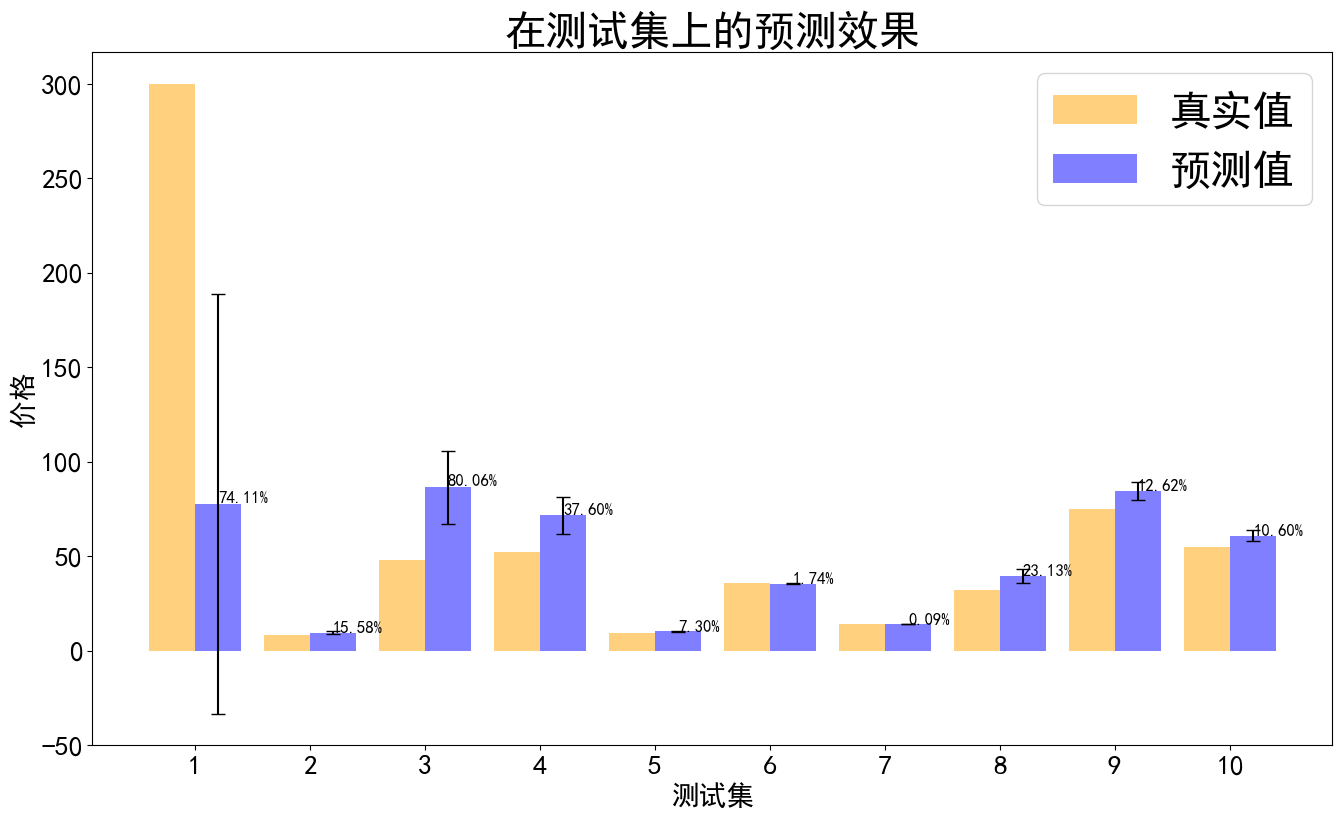

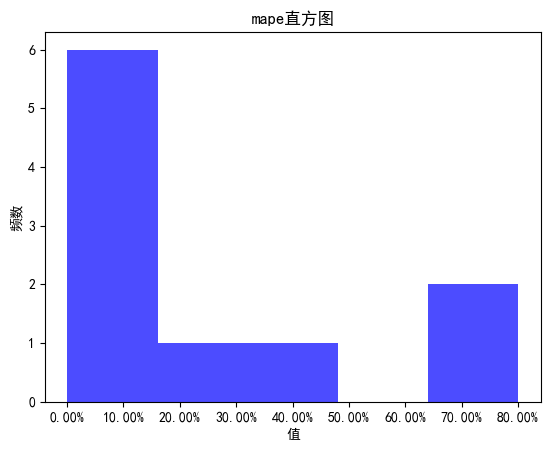

In [34]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error

def xgboost(X_train, y_train, X_test, y_test):
    parameters = {
        'max_depth': [5,7],
        'n_estimators': [100,300,500],
        'learning_rate': [0.01,0.1],
        'min_child_weight': [3,5,7],
        'subsample':[0.7,0.9,1],
        'colsample_bytree':[0.7,0.9,1]
    }

    # 创建 GridSearchCV 对象
    grid_xgb = GridSearchCV(
        estimator=xgb.XGBRegressor(),
        param_grid=parameters,
        cv=10,  # 交叉验证折数
        scoring='neg_mean_absolute_error',  # 使用负平均绝对误差作为回归问题的评估指标
        n_jobs=6
    )

    grid_xgb.fit(X_train, y_train)

    # 创建 XGBoostRegressor 模型
    xgb_model = xgb.XGBRegressor(max_depth=grid_xgb.best_params_['max_depth'],
                                 n_estimators=grid_xgb.best_params_['n_estimators'],
                                 min_child_weight=grid_xgb.best_params_['min_child_weight'],
                                 learning_rate=grid_xgb.best_params_['learning_rate'],
                                 subsample=grid_xgb.best_params_['subsample'],
                                 colsample_bytree=grid_xgb.best_params_['colsample_bytree'],
                                 )

    # 训练模型
    xgb_model.fit(X_train, y_train)
    print("最好",grid_xgb.best_params_)
    # 在测试集上进行预测
    grid_xgb_pred = xgb_model.predict(X_test)
    grid_xgb_pred = np.exp(grid_xgb_pred)
    # 模型分析
    # 计算每个测试样本的残差
    residuals = y_test - grid_xgb_pred

    # 计算残差的标准差
    std_dev = np.std(residuals)

    model8_mse = mean_squared_error(y_test, grid_xgb_pred)
    print("均方误差 (MSE):", model8_mse)
    model8_rmse = np.sqrt(model8_mse)
    print("均方根误差 (RMSE):", model8_rmse)
    model8_mae = mean_absolute_error(y_test, grid_xgb_pred)
    print("平均绝对误差 (MAE):", model8_mae)
    model8_r2 = r2_score(y_test, grid_xgb_pred)
    print("R^2 得分:", model8_r2)
    lower_bounds, upper_bounds = calculate_confidence_intervals(grid_xgb_pred, std_dev)
    confidence_intervals = list(zip(lower_bounds, upper_bounds))
    print("95% 的置信区间列表:", confidence_intervals)
    XGlibi=abs(grid_xgb_pred/y_test-1)
    print("平均绝对误差百分比:",XGlibi.mean())
    return xgb_model, grid_xgb_pred
xgb_model, grid_xgb_pred = xgboost(X_train, y_train, X_test, y_test)
draw_result(grid_xgb_pred, X_test, y_test)
draw_mapes_hist(y_test, grid_xgb_pred)

In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import numpy as np

def xgboost(X_train, y_train, X_test, y_test):
    # 定义参数分布而不是固定值列表
    param_dist = {
        'max_depth': randint(3, 10),  # 3到9之间的随机整数
        'n_estimators': randint(50, 501),  # 50到500之间的随机整数
        'learning_rate': uniform(0.01, 0.3),  # 0.01到0.31之间的均匀分布
        'min_child_weight': randint(1, 10),  # 1到9之间的随机整数
        'subsample': uniform(0.5, 0.5),  # 0.5到1.0之间的均匀分布
        'colsample_bytree': uniform(0.5, 0.5)  # 0.5到1.0之间的均匀分布
    }

    # 创建 RandomizedSearchCV 对象
    random_xgb = RandomizedSearchCV(
        estimator=xgb.XGBRegressor(random_state=42),
        param_distributions=param_dist,
        n_iter=50,  # 尝试50种随机参数组合
        cv=5,       # 减少交叉验证折数
        scoring='neg_mean_absolute_error',
        n_jobs=6,   # 使用6个核心
        random_state=42,  # 确保结果可重现
        verbose=1    # 显示进度信息
    )

    # 执行参数搜索
    random_xgb.fit(X_train, y_train)

    # 获取最佳参数组合
    best_params = random_xgb.best_params_
    print("最佳参数:", best_params)
    
    # 直接使用最佳模型进行预测，避免重复训练
    xgb_model = random_xgb.best_estimator_
    
    # 使用模型进行预测
    grid_xgb_pred = xgb_model.predict(X_test)
    grid_xgb_pred = np.exp(grid_xgb_pred)
    
    # 模型分析
    # 计算每个测试样本的残差
    residuals = y_test - grid_xgb_pred

    # 计算残差的标准差
    std_dev = np.std(residuals)
    model8_mse = mean_squared_error(y_test, grid_xgb_pred)
    print("均方误差 (MSE):", model8_mse)
    model8_rmse = np.sqrt(model8_mse)
    print("均方根误差 (RMSE):", model8_rmse)
    model8_mae = mean_absolute_error(y_test, grid_xgb_pred)
    print("平均绝对误差 (MAE):", model8_mae)
    model8_r2 = r2_score(y_test, grid_xgb_pred)
    print("R^2 得分:", model8_r2)
    lower_bounds, upper_bounds = calculate_confidence_intervals(grid_xgb_pred, std_dev)
    confidence_intervals = list(zip(lower_bounds, upper_bounds))
    print("95% 的置信区间列表:", confidence_intervals)
    XGlibi = abs(grid_xgb_pred/y_test-1)
    print("平均绝对误差百分比:", XGlibi.mean())
    
    return xgb_model, grid_xgb_pred

xgb_model, grid_xgb_pred = xgboost(X_train, y_train, X_test, y_test)
draw_result(grid_xgb_pred, X_test, y_test)
draw_mapes_hist(y_test, grid_xgb_pred)

In [35]:
xgb_r2, xgb_ci_width, xgb_stability = new_3_indictors(df_X, df_y,X_test, y_test, grid_xgb_pred, xgb_model, 'XGBoost')

R² score: 0.22810869331214323
Confidence Interval Width: [58.988815 58.988823 58.988815 58.988815 58.988823 58.988823 58.988823
 58.988815 58.988815 58.988815]
Model Stability (Std of MAPE): 0.0864225763211636
R² score is too low.
Confidence interval width is acceptable.
Model stability is acceptable.


ValueError: operands could not be broadcast together with remapped shapes [original->remapped]: (26,)  and requested shape (27,)

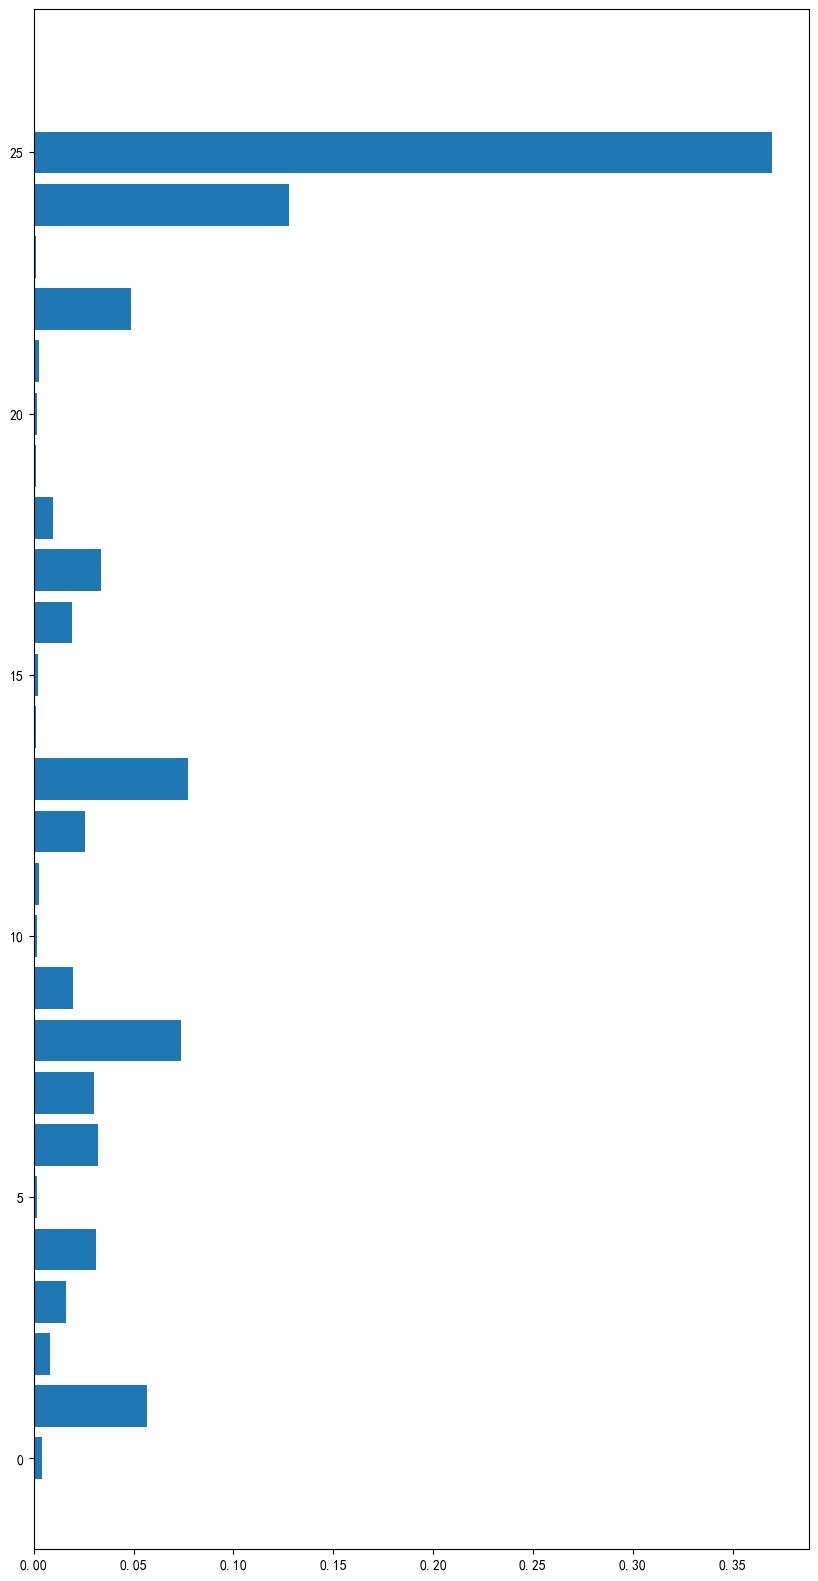

In [36]:
xgb_importance = xgb_model.feature_importances_
plt.figure(figsize=(10,20))
plt.barh(range(len(xgb_importance)),xgb_importance,tick_label=X_train.columns)
plt.xlabel('Feature importance')
plt.title('xgb feature importance')
plt.show()
print(xgb_importance)

In [34]:
import numpy as np
from sklearn.ensemble import IsolationForest

# 创建一个包含所有数据的数组，其中每一行是一种模型的预测结果
data = np.array([
    lasso_predictions,
    ridge_predictions,
    #grid_xgb_pred,
    grid_rf_pred,
    grid_et_pred,
    grid_svr_pred,
    grid_gbdt_pred
])

lasso_mape_weight = mean_absolute_percentage_error(y_test, lasso_predictions)
ridge_mape_weight = mean_absolute_percentage_error(y_test, ridge_predictions)
xgb_mape_weight = mean_absolute_percentage_error(y_test, grid_xgb_pred)
rf_mape_weight = mean_absolute_percentage_error(y_test, grid_rf_pred)
et_mape_weight = mean_absolute_percentage_error(y_test, grid_et_pred)
svr_mape_weight = mean_absolute_percentage_error(y_test, grid_svr_pred)
gbdt_mape_weight = mean_absolute_percentage_error(y_test, grid_gbdt_pred)

weight_score = 99-max(lasso_mape_weight,
                   ridge_mape_weight,
                   #xgb_mape_weight,
                   rf_mape_weight,
                   et_mape_weight,
                   svr_mape_weight,
                   gbdt_mape_weight)

lasso_weight = 100 - mean_absolute_percentage_error(y_test, lasso_predictions)-weight_score
ridge_weight = 100 - mean_absolute_percentage_error(y_test, ridge_predictions)-weight_score
#xgb_weight = 100 - mean_absolute_percentage_error(y_test, grid_xgb_pred)-weight_score
rf_weight = 100 - mean_absolute_percentage_error(y_test, grid_rf_pred)-weight_score
et_weight = 100 - mean_absolute_percentage_error(y_test, grid_et_pred)-weight_score
svr_weight = 100 - mean_absolute_percentage_error(y_test, grid_svr_pred)-weight_score
gbdt_weight = 100 - mean_absolute_percentage_error(y_test, grid_gbdt_pred)-weight_score
weights = np.array([lasso_weight,
                    ridge_weight,
                    #xgb_weight,
                    rf_weight,
                    et_weight,
                    svr_weight,
                    gbdt_weight])
print("weight：", weights)
weights /= np.sum(weights)

print("weight：", weights)

print("原y_pred：")
print(data.T)
# 初始化孤立森林模型
clf = IsolationForest(n_estimators=300, 
                      max_samples='auto', 
                      contamination=float(0.1),
                      max_features=1.0)  # contamination参数表示预期的离群值比例

# 存储每列的平均值
column_means = []
cleaned_data = []
ocolumn_means = []

# 对每列数据进行拟合和预测
for column in data.T:  # 转置以便迭代列
    # 拟合孤立森林模型
    clf.fit(column.reshape(-1, 1))  # 转换为列向量
    
    # 预测离群值
    predictions = clf.predict(column.reshape(-1, 1))
    
    # 去除离群值并计算平均值
#     clean_column = column[predictions == 1]  # 去除离群值
#     cleaned_data.append(clean_column)
    clean_column = column.copy()
    clean_column[predictions == -1] = np.nan  # 替换离群值为NaN
    cleaned_data.append(clean_column)
    column_mean = np.nanmean(clean_column)   # 计算平均值
    column_means.append(column_mean)

# column_means 现在包含了每列数据的平均值
cleaned_data = np.array(cleaned_data)
print("去除离群值后的y_pred:")
print(cleaned_data)
print("每列数据的平均值:", column_means)

weight_column_means = np.dot(data.T, weights)
print("权重每列数据的平均值:", weight_column_means)

weight_mean_absolute_error_percentage = np.mean(np.abs((y_test - weight_column_means) / y_test) )
print("权重平均绝对误差百分比:", weight_mean_absolute_error_percentage)
draw_result(weight_column_means, X_test, y_test)

for column in data.T:  # 转置以便迭代列
    o_column = column.copy()
    ocolumn_mean = np.mean(o_column)
    ocolumn_means.append(ocolumn_mean)

print("没去除坏值的每列数据的平均值:", ocolumn_means)

# 计算没去除坏值的平均绝对误差百分比
no_drop_mean_absolute_error_percentage = np.mean(np.abs((y_test - ocolumn_means) / y_test) )
print("没去除坏值的平均绝对误差百分比:", no_drop_mean_absolute_error_percentage)
draw_result(ocolumn_means, X_test, y_test)

# 计算去除坏值的平均绝对误差百分比
drop_mean_absolute_error_percentage = np.mean(np.abs((y_test - column_means) / y_test) )
print("平均绝对误差百分比:", drop_mean_absolute_error_percentage)
draw_result(column_means, X_test, y_test)

NameError: name 'grid_xgb_pred' is not defined

weight： [1.09427852 1.01479156 1.43817804 1.10141938 1.         1.47212717]
weight： [0.15367365 0.142511   0.20196876 0.15467647 0.14043376 0.20673636]
原y_pred：
[[22.75148906 20.90892856 20.97617696 23.22062277 17.31029854 24.91838272]
 [11.50612615 11.28514487  8.2        12.77157573  9.37188692  9.00289096]
 [40.52545403 48.467027   34.98571137 38.38119116 51.40350021 36.29241603]
 [13.89698381 14.63538915  5.47722558 14.55313181 14.70049628  5.47378617]
 [89.37623731 91.37449688 87.71805997 82.28410851 98.24336197 75.01896657]
 [55.50299785 51.75755918 48.69777262 49.45600122 52.90587554 48.95756762]
 [10.83658182 10.99206966 14.65897209 14.85618811  9.06043172 14.80963259]
 [28.13886464 22.19555354 40.         36.76653328 30.873506   40.01396809]
 [41.28657397 38.18653926 48.69777262 32.92856835 35.95246579 46.70845962]
 [29.99641831 23.29885782 33.46640106 32.76259064 21.56710312 43.61280633]]
去除离群值后的y_pred:
[[22.75148906 20.90892856 20.97617696 23.22062277         nan 24.91838272

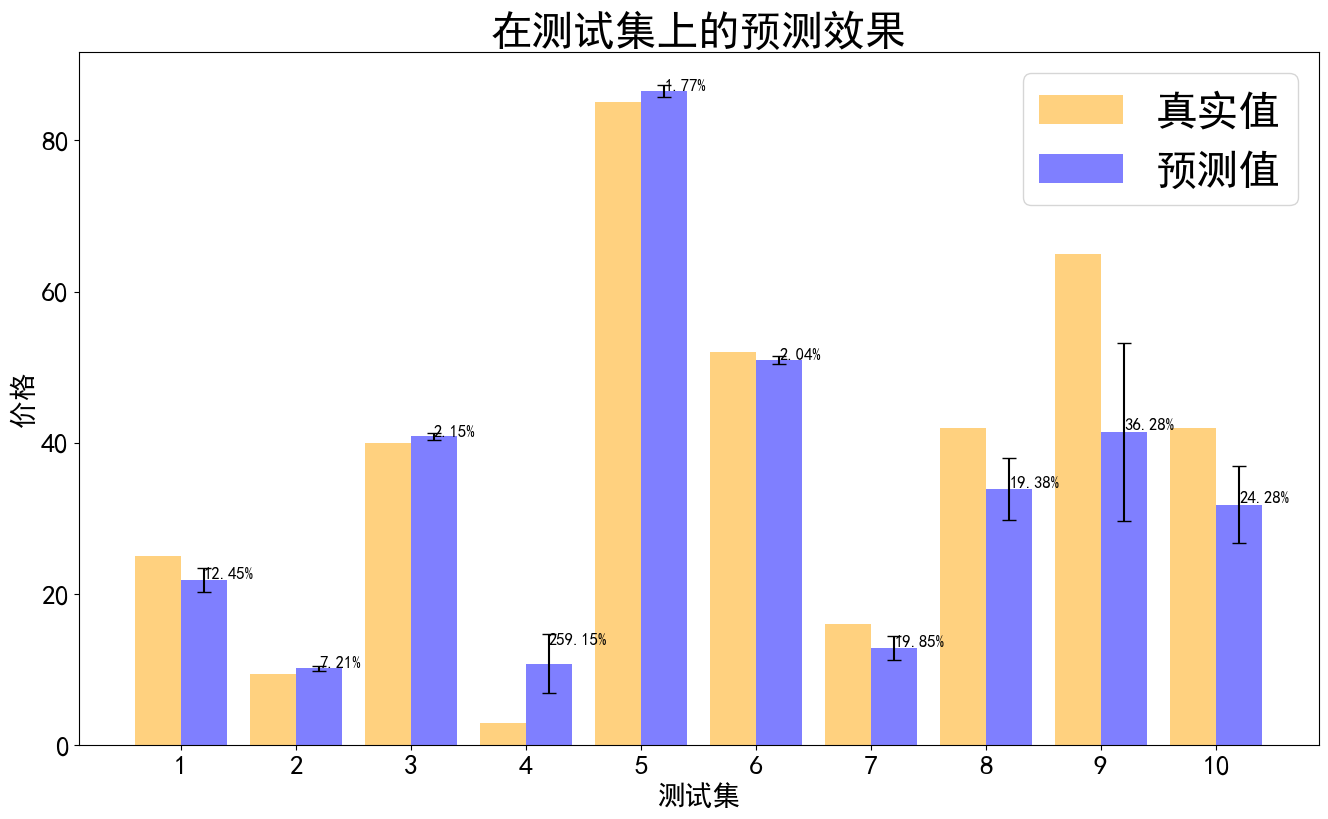

加权平均均方误差 (MSE): 81.10496759408201
加权平均均方根误差 (RMSE): 9.005829644962313
加权平均平均绝对误差 (MAE): 6.008919481167141
R^2 得分: 0.8616009323975069
权重平均绝对误差百分比: 0.38456090238258683


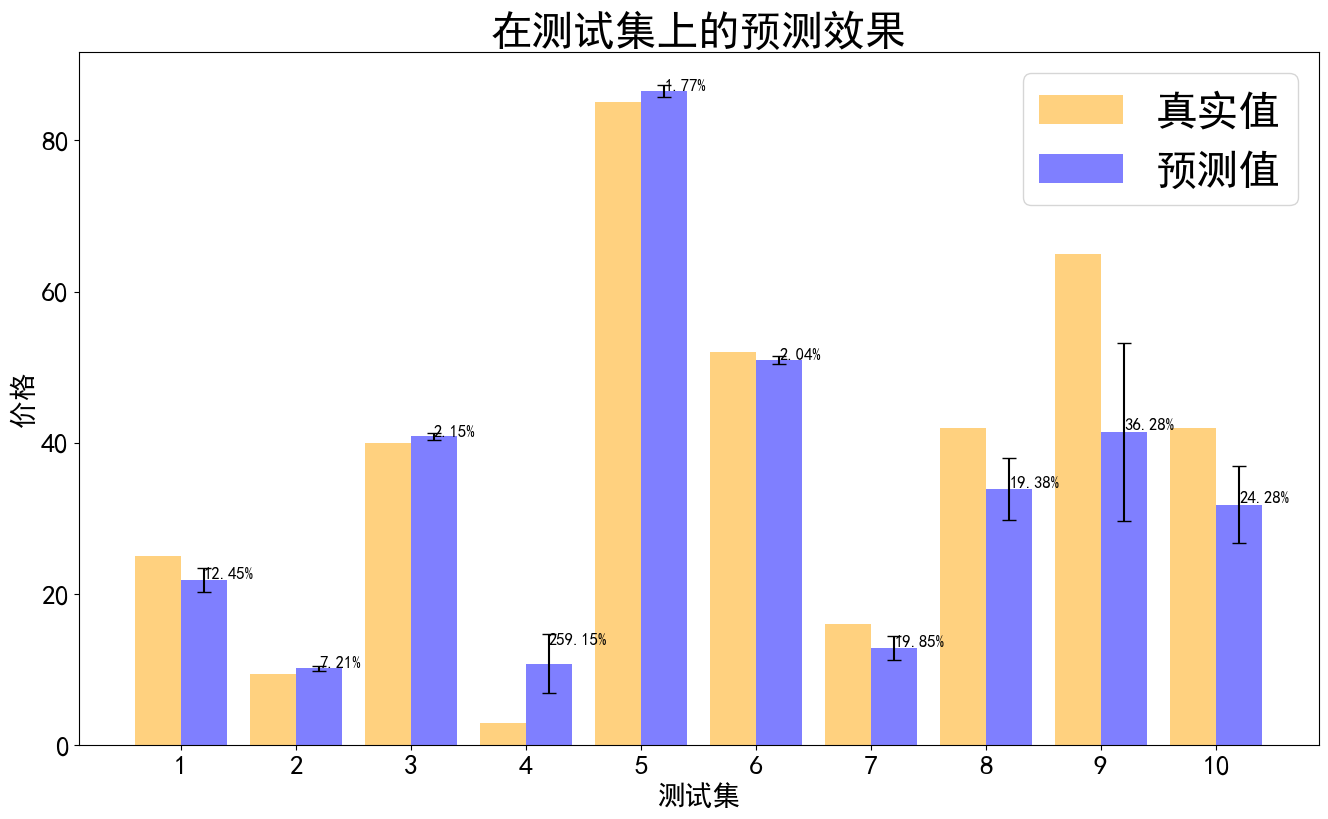

没去除坏值的每列数据的平均值: [21.680983103039893, 10.356270769744135, 41.67588330071859, 11.456168801041605, 87.33587186981687, 51.21296233881811, 12.535645997984373, 32.99807092561001, 40.62672993423285, 30.78402954630684]
没去除坏值的均方误差 (MSE): 81.10496759408201
没去除坏值的均方根误差 (RMSE): 9.513311393640233
没去除坏值的平均绝对误差 (MAE): 6.548577289532912
R^2 得分: 0.8455637903453108
没去除坏值的平均绝对误差百分比: 0.4199004713424118


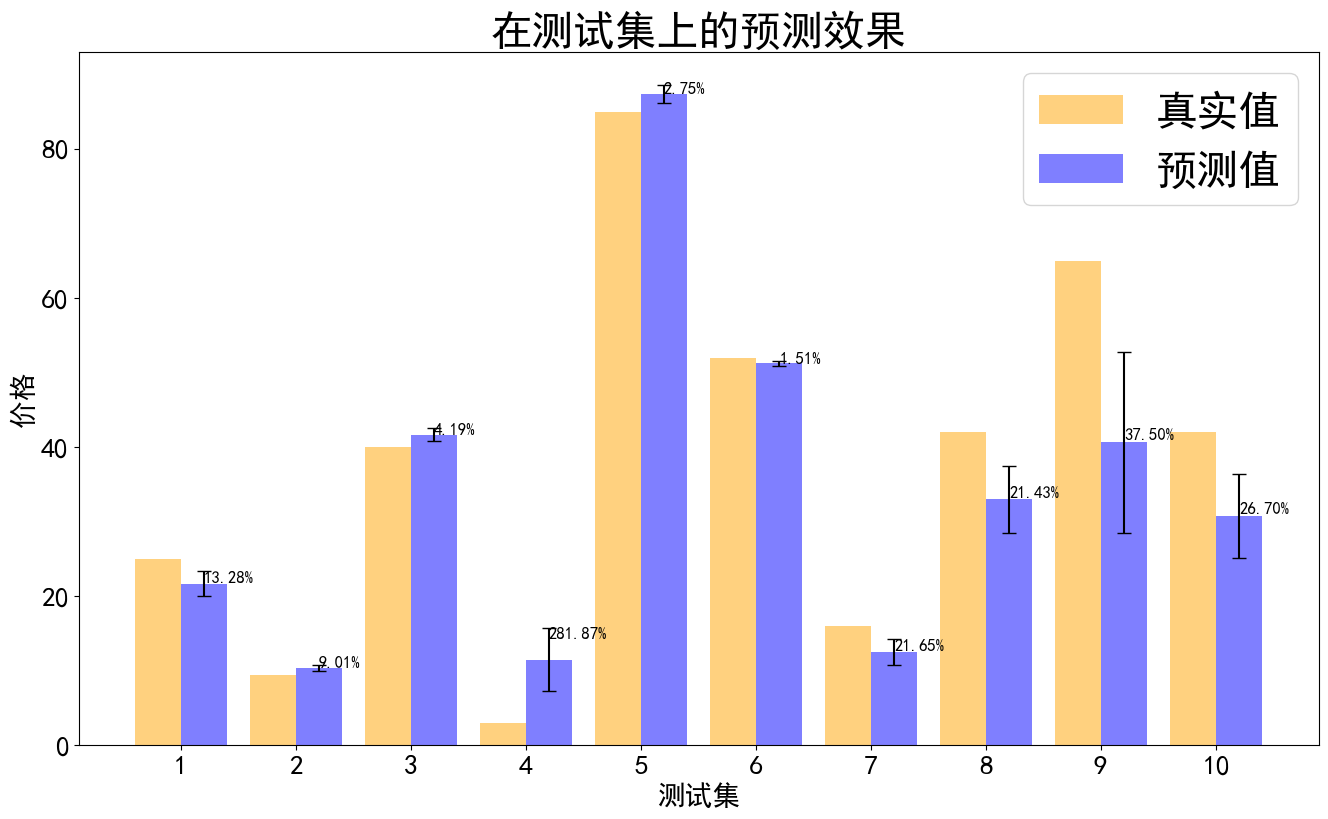

平均绝对误差百分比: 0.44648632548069617


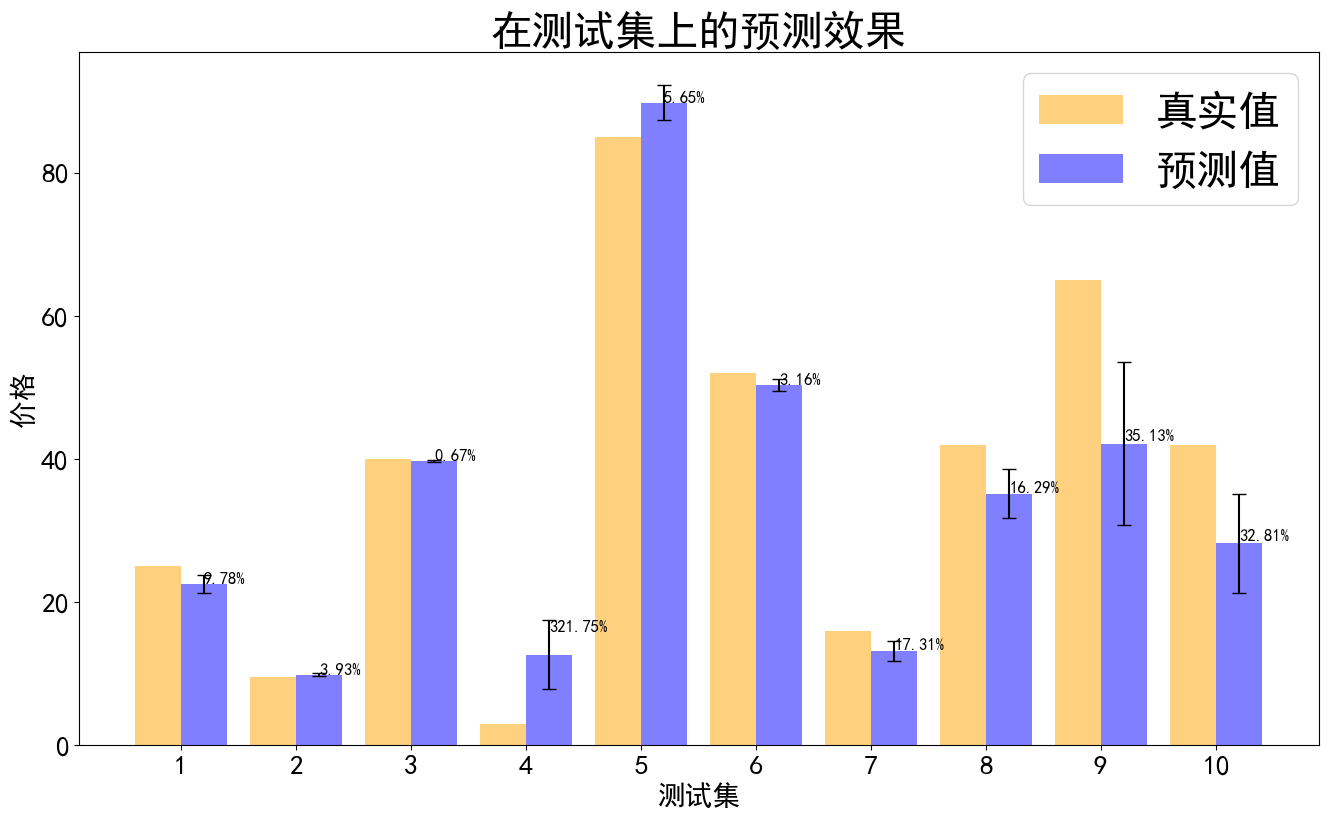

去除坏值的均方误差 (MSE): 89.08871598217118
去除坏值的均方根误差 (RMSE): 9.43868189855825
去除坏值的平均绝对误差 (MAE): 6.541077316866686
R^2 得分: 0.8479773114817756


In [35]:
import numpy as np
from sklearn.ensemble import IsolationForest

# 创建一个包含所有数据的数组，其中每一行是一种模型的预测结果
data = np.array([
    lasso_predictions,
    ridge_predictions,
    #grid_xgb_pred,
    grid_rf_pred,
    grid_et_pred,
    grid_svr_pred,
    grid_gbdt_pred
])

lasso_mape_weight = mean_absolute_percentage_error(y_test, lasso_predictions)
ridge_mape_weight = mean_absolute_percentage_error(y_test, ridge_predictions)
#xgb_mape_weight = mean_absolute_percentage_error(y_test, grid_xgb_pred)
rf_mape_weight = mean_absolute_percentage_error(y_test, grid_rf_pred)
et_mape_weight = mean_absolute_percentage_error(y_test, grid_et_pred)
svr_mape_weight = mean_absolute_percentage_error(y_test, grid_svr_pred)
gbdt_mape_weight = mean_absolute_percentage_error(y_test, grid_gbdt_pred)

weight_score = 99-max(lasso_mape_weight,
                   ridge_mape_weight,
                   #xgb_mape_weight,
                   rf_mape_weight,
                   et_mape_weight,
                   svr_mape_weight,
                   gbdt_mape_weight)

lasso_weight = 100 - mean_absolute_percentage_error(y_test, lasso_predictions)-weight_score
ridge_weight = 100 - mean_absolute_percentage_error(y_test, ridge_predictions)-weight_score
#xgb_weight = 100 - mean_absolute_percentage_error(y_test, grid_xgb_pred)-weight_score
rf_weight = 100 - mean_absolute_percentage_error(y_test, grid_rf_pred)-weight_score
et_weight = 100 - mean_absolute_percentage_error(y_test, grid_et_pred)-weight_score
svr_weight = 100 - mean_absolute_percentage_error(y_test, grid_svr_pred)-weight_score
gbdt_weight = 100 - mean_absolute_percentage_error(y_test, grid_gbdt_pred)-weight_score
weights = np.array([lasso_weight,
                    ridge_weight,
                    #xgb_weight,
                    rf_weight,
                    et_weight,
                    svr_weight,
                    gbdt_weight])
print("weight：", weights)
weights /= np.sum(weights)
np.save("ensemble_weights.npy", weights)
print("weight：", weights)

print("原y_pred：")
print(data.T)
# 初始化孤立森林模型
clf = IsolationForest(n_estimators=300, 
                      max_samples='auto', 
                      contamination=float(0.1),
                      max_features=1.0)  # contamination参数表示预期的离群值比例

# 存储每列的平均值
column_means = []
cleaned_data = []
ocolumn_means = []

# 对每列数据进行拟合和预测
for column in data.T:  # 转置以便迭代列
    # 拟合孤立森林模型
    clf.fit(column.reshape(-1, 1))  # 转换为列向量
    
    # 预测离群值
    predictions = clf.predict(column.reshape(-1, 1))
    
    # 去除离群值并计算平均值
#     clean_column = column[predictions == 1]  # 去除离群值
#     cleaned_data.append(clean_column)
    clean_column = column.copy()
    clean_column[predictions == -1] = np.nan  # 替换离群值为NaN
    cleaned_data.append(clean_column)
    column_mean = np.nanmean(clean_column)   # 计算平均值
    column_means.append(column_mean)

# column_means 现在包含了每列数据的平均值
cleaned_data = np.array(cleaned_data)
print("去除离群值后的y_pred:")
print(cleaned_data)
print("每列数据的平均值:", column_means)

weight_column_means = np.dot(data.T, weights)
print("权重每列数据的平均值:", weight_column_means)

weight_mean_absolute_error_percentage = np.mean(np.abs((y_test - weight_column_means) / y_test) )
print("权重平均绝对误差百分比:", weight_mean_absolute_error_percentage)
draw_result(weight_column_means, X_test, y_test)


weight_column_means_mse = mean_squared_error(y_test, weight_column_means)
print("加权平均均方误差 (MSE):", weight_column_means_mse)
weight_column_means_rmse = np.sqrt(weight_column_means_mse)
print("加权平均均方根误差 (RMSE):", weight_column_means_rmse)
weight_column_means_mae = mean_absolute_error(y_test, weight_column_means)
print("加权平均平均绝对误差 (MAE):",weight_column_means_mae)
weight_column_means_r2 = r2_score(y_test, weight_column_means)
print("R^2 得分:", weight_column_means_r2)

weight_mean_absolute_error_percentage = np.mean(np.abs((y_test - weight_column_means) / y_test) )
print("权重平均绝对误差百分比:", weight_mean_absolute_error_percentage)
draw_result(weight_column_means, X_test, y_test)

for column in data.T:  # 转置以便迭代列
    o_column = column.copy()
    ocolumn_mean = np.mean(o_column)
    ocolumn_means.append(ocolumn_mean)

print("没去除坏值的每列数据的平均值:", ocolumn_means)

ocolumn_means_mse = mean_squared_error(y_test,ocolumn_means)
print("没去除坏值的均方误差 (MSE):", weight_column_means_mse)
ocolumn_means_rmse = np.sqrt(ocolumn_means_mse)
print("没去除坏值的均方根误差 (RMSE):", ocolumn_means_rmse)
ocolumn_means_mae = mean_absolute_error(y_test,ocolumn_means)
print("没去除坏值的平均绝对误差 (MAE):",ocolumn_means_mae)
ocolumn_means_r2 = r2_score(y_test, ocolumn_means)
print("R^2 得分:", ocolumn_means_r2)

# 计算没去除坏值的平均绝对误差百分比
no_drop_mean_absolute_error_percentage = np.mean(np.abs((y_test - ocolumn_means) / y_test) )
print("没去除坏值的平均绝对误差百分比:", no_drop_mean_absolute_error_percentage)
draw_result(ocolumn_means, X_test, y_test)

# 计算去除坏值的平均绝对误差百分比
drop_mean_absolute_error_percentage = np.mean(np.abs((y_test - column_means) / y_test) )
print("平均绝对误差百分比:", drop_mean_absolute_error_percentage)
draw_result(column_means, X_test, y_test)

column_means_mse = mean_squared_error(y_test,column_means)
print("去除坏值的均方误差 (MSE):",column_means_mse)
column_means_rmse = np.sqrt(column_means_mse)
print("去除坏值的均方根误差 (RMSE):", column_means_rmse)
column_means_mae = mean_absolute_error(y_test,column_means)
print("去除坏值的平均绝对误差 (MAE):",column_means_mae)
column_means_r2 = r2_score(y_test, column_means)
print("R^2 得分:", column_means_r2)

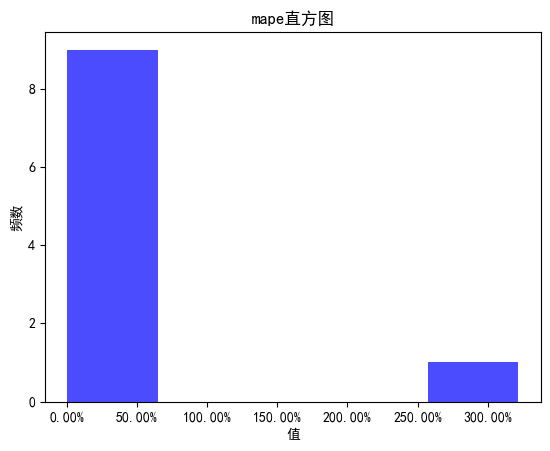

In [36]:
draw_mapes_hist(y_test, column_means)

In [37]:
total_r2 = np.array([
    lasso_r2,
    ridge_r2,
    #xgb_r2,
    rf_r2,
    et_r2,
    svr_r2,
    gbdt_r2
])

total_ci_width = np.array([
    lasso_ci_width,
    ridge_ci_width,
    #xgb_ci_width,
    rf_ci_width,
    et_ci_width,
    svr_ci_width,
    gbdt_ci_width
])
total_stability = np.array([
    lasso_stability,
    ridge_stability,
    #xgb_stability,
    rf_stability,
    et_stability,
    svr_stability,
    gbdt_stability
])

print(y_test)
final_r2 = r2_score(y_test, column_means)
final_ci_width = np.mean(total_ci_width)
final_stability = np.mean(total_stability) / 100
print("集成模型的R2：", final_r2)
print("集成模型的80%置信区间宽度：", final_ci_width)
print("集成模型的稳定性：",final_stability)

17    25.0
46     9.5
39    40.0
26     3.0
1     85.0
42    52.0
49    16.0
47    42.0
8     65.0
2     42.0
Name: 价格_万元, dtype: float64
集成模型的R2： 0.8479773114817756
集成模型的80%置信区间宽度： 45.35200696727896
集成模型的稳定性： 0.00354613550370716


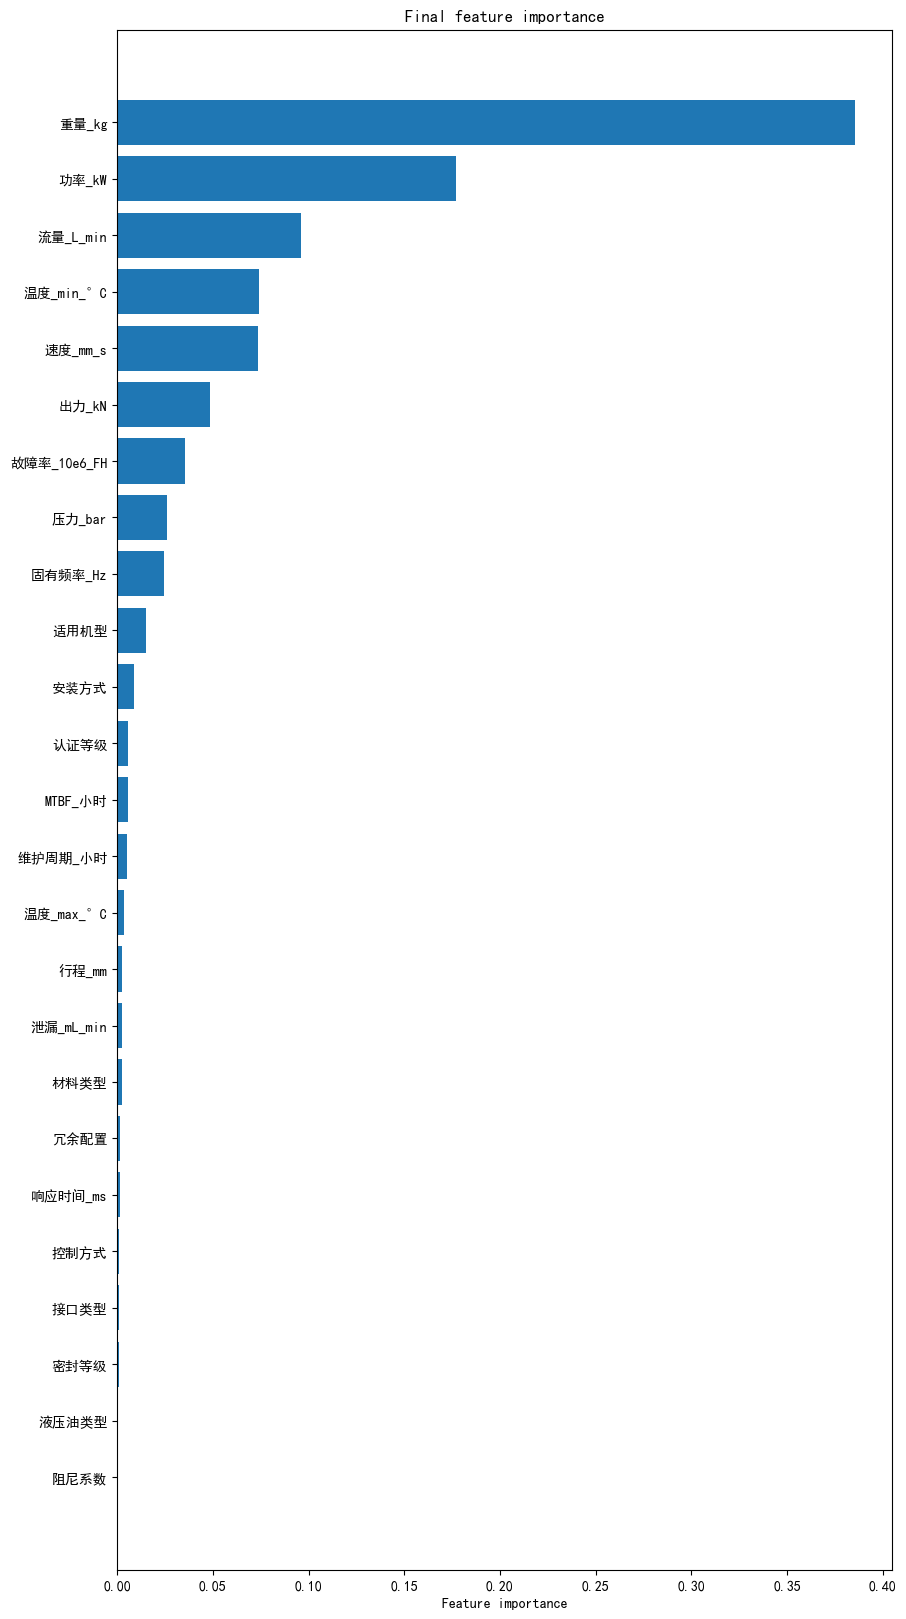

In [38]:
total_importance = np.array([
    #xgb_importance,
    #rf_importance,
    et_importance,
    gbdt_importance
])
final_importance = np.mean(total_importance, axis=0)


importance_label = X_train.columns.values

paired_importance = list(zip(final_importance,importance_label))

paired_sorted_importance = sorted(paired_importance)
sorted_importance, sorted_label = zip(*paired_sorted_importance)

plt.figure(figsize=(10,20))
plt.barh(range(len(sorted_importance)),sorted_importance,tick_label=sorted_label)
plt.xlabel('Feature importance')
plt.title('Final feature importance')
plt.savefig('feature_importance.png')
plt.show()
#把该图保存到当前文件夹

In [39]:
import pickle
with open('lasso.pkl','wb') as file: pickle.dump(lasso_model, file)
with open('ridge.pkl','wb') as file: pickle.dump(ridge_model, file)
with open('svr.pkl','wb') as file: pickle.dump(svr_model, file)
with open('gbdt.pkl','wb') as file: pickle.dump(gbdt_model, file)
with open('et.pkl','wb') as file: pickle.dump(et_model, file)
with open('rf.pkl','wb') as file: pickle.dump(rf_model, file)
#with open('xgb.pkl','wb') as file: pickle.dump(xgb_model, file)

In [45]:
import pickle


model_paths = {
    "lasso": "lasso.pkl",
    "ridge": "ridge.pkl",
    "gbdt": "gbdt.pkl",
    "svr": "svr.pkl",
    "rf": "rf.pkl",
    "et": "et.pkl"
}


for name,path in model_paths.items():

    with open(path,"rb") as f:
        model=pickle.load(f)

    print("\n======",name,"======")

    if hasattr(model,"intercept_"):
        print(
            "intercept:",
            model.intercept_
        )

    if hasattr(model,"n_features_in_"):
        print(
            "feature数:",
            model.n_features_in_
        )


====== lasso ======
intercept: -40.31244855796399
feature数: 25

====== ridge ======
intercept: -40.467466294369444
feature数: 25

====== gbdt ======
feature数: 25

====== svr ======
intercept: [-166.68326012]
feature数: 25

====== rf ======

====== et ======
feature数: 25


In [13]:
import pickle
import numpy as np
import pandas as pd


# ============================
# 1. 加载 scaler
# ============================

scaler_path = "minmax.pkl"


with open(scaler_path, "rb") as f:
    scaler = pickle.load(f)


print("===================")
print("Scaler类型:")
print(type(scaler))


# ============================
# 2. 查看Scaler基本信息
# ============================

print("\n===================")
print("Scaler信息")


if hasattr(scaler, "n_features_in_"):
    print(
        "特征数量:",
        scaler.n_features_in_
    )


if hasattr(scaler, "feature_names_in_"):
    print(
        "特征名称:"
    )
    print(
        scaler.feature_names_in_
    )


print("\ndata_min_:")
print(scaler.data_min_)


print("\ndata_max_:")
print(scaler.data_max_)


print("\ndata_range_:")
print(scaler.data_range_)



# ============================
# 3. 测试一个样本
# ============================

# 这里换成你的实际一条原始数据
sample = pd.DataFrame({

    "压力_bar":[100],
    "出力_kN":[50],
    "行程_mm":[200],
    "速度_mm_s":[100],
    "温度_min_°C":[-20],
    "温度_max_°C":[80],
    "MTBF_小时":[50000],
    "重量_kg":[30],
    "功率_kW":[5],
    "泄漏_mL_min":[1],
    "响应时间_ms":[20],
    "控制方式":[2],
    "适用机型":[3],
    "材料类型":[1],
    "密封等级":[2],
    "液压油类型":[1],
    "流量_L_min":[50],
    "固有频率_Hz":[100],
    "阻尼系数":[0.5],
    "冗余配置":[1],
    "认证等级":[2],
    "维护周期_小时":[10000],
    "故障率_10e6_FH":[0.1],
    "安装方式":[1],
    "接口类型":[1]

})


print("\n===================")
print("输入维度:")
print(sample.shape)


# ============================
# 4. scaler转换
# ============================

scaled = scaler.transform(sample)


scaled_df = pd.DataFrame(
    scaled,
    columns=sample.columns
)


print("\n归一化结果:")
print(scaled_df)


print("\n最大值:")
print(scaled_df.max(axis=1))

print("\n最小值:")
print(scaled_df.min(axis=1))

Scaler类型:
<class 'sklearn.preprocessing._data.MinMaxScaler'>

Scaler信息
特征数量: 25
特征名称:
['压力_bar' '出力_kN' '行程_mm' '速度_mm_s' '温度_min_°C' '温度_max_°C' 'MTBF_小时'
 '重量_kg' '功率_kW' '泄漏_mL_min' '响应时间_ms' '控制方式' '适用机型' '材料类型' '密封等级' '液压油类型'
 '流量_L_min' '固有频率_Hz' '阻尼系数' '冗余配置' '认证等级' '维护周期_小时' '故障率_10e6_FH' '安装方式'
 '接口类型']

data_min_:
[1.65e+02 8.00e+00 1.20e+01 8.00e+00 4.00e+01 8.00e+01 8.00e+03 4.80e-01
 2.00e-03 0.00e+00 5.00e+00 1.00e+00 1.00e+00 1.00e+00 1.00e+00 1.00e+00
 5.00e+00 1.50e+01 5.00e-01 1.00e+00 1.00e+00 3.00e+03 1.50e-01 1.00e+00
 1.00e+00]

data_max_:
[3.80e+02 3.50e+02 7.00e+02 9.72e+02 6.00e+01 2.00e+02 4.00e+04 1.20e+02
 3.37e+02 5.00e+02 3.00e+02 1.90e+01 1.30e+01 7.00e+00 4.00e+00 3.00e+00
 4.50e+02 1.50e+02 1.00e+00 4.00e+00 5.00e+00 2.00e+04 2.50e+00 6.00e+00
 3.00e+00]

data_range_:
[2.15000e+02 3.42000e+02 6.88000e+02 9.64000e+02 2.00000e+01 1.20000e+02
 3.20000e+04 1.19520e+02 3.36998e+02 5.00000e+02 2.95000e+02 1.80000e+01
 1.20000e+01 6.00000e+00 3.00000e+00 2.000

In [ ]:
from services.price_service.export_native_price_bundle import export_price_service_bundle

# 唯一必须确认的配置：与本批成品数据使用同一个代号。
PRODUCT_CODE = "AIRCRAFT_CABIN_DOOR_LOCK_FINAL_TEST"

# 原价格单位若为元填10000；已经是万元填1。
TARGET_DIVISOR_TO_WAN = 10000

# 可选：不设置时自动使用当前Notebook内已经训练成功的全部模型。
# PRICE_ENSEMBLE_MODELS = ["ridge", "svr", "gbdt"]
# PRICE_ENSEMBLE_WEIGHTS = {"ridge": 0.5, "svr": 0.2, "gbdt": 0.3}

bundle = export_price_service_bundle(globals())

print("已直接安装到独立价格服务：services/price_service/model/price_native_bundle.pkl")
print("实际保存模型数量：", bundle["export_notes"]["included_model_count"])
print("实际保存模型：", bundle["export_notes"]["included_models"])
print("权重来源：", bundle["export_notes"]["weight_source"])
print("集成配置：", bundle["ensemble"])
print("所需依赖模块：", bundle["required_modules"])
